# **Validation & Monitoring Pipeline: Cocaine Seizures DB (2025)**

InSight Crime - MAD Unit 

---------------------


## Setup

#### Version Control

The project is created within a single GitHub repository ([FelipeVillota/db-check](https://github.com/FelipeVillota/db-check-cocaine-seizures)). I keep the repository `private` with the possibility to give access to the online repo at any time. 

#### Environment

In [1]:
import os
import subprocess
import sys

# Subprocess Scripting Automation to manage and reproduce Python virtual environment and prepare packages

# Define environment name and path
venv_name = "venv-db-check"
venv_path = os.path.join(os.getcwd(), venv_name)

# 1. Create the virtual environment if it doesn't exist
if not os.path.exists(venv_path):
    # On Linux Mint, ensure python3-venv is installed
    try:
        subprocess.run([sys.executable, "-m", "venv", venv_path], check=True)
        print(f"✅ Created virtual environment: {venv_name}")
    except subprocess.CalledProcessError as e:
        sys.exit(1)
else:
    print(f"✅ Virtual environment '{venv_name}' already exists.")

# 2. Define the venv's python executable (Linux-specific)
venv_python = os.path.join(venv_path, "bin", "python")

# Safety check with more descriptive error
if not os.path.exists(venv_python):
    raise FileNotFoundError(
        f"Python executable not found at {venv_python}"
    )

# 3. Install and upgrade packages
packages = [
    "gspread", "pandas", "requests", "google-api-python-client",
    "oauth2client", "matplotlib", "seaborn", "missingno",
    "gspread-formatting", "ipykernel", "openpyxl"
]

# Get list of already installed packages
try:
    result = subprocess.run(
        [venv_python, "-m", "pip", "freeze"],
        capture_output=True, text=True, check=True
    )
    installed_packages = result.stdout.lower()
except subprocess.CalledProcessError:
    installed_packages = ""
    print("⚠️ No packages installed yet in virtual environment")

# Check if all required packages are already installed
missing = [pkg for pkg in packages if not any(pkg.lower() in line for line in installed_packages.splitlines())]

if missing:
    print(f"⚠️ Missing packages: {missing}")
    subprocess.run([venv_python, "-m", "pip", "install", "--upgrade", "pip"], check=True)
    subprocess.run([venv_python, "-m", "pip", "install"] + missing, check=True)
    print("✅ Installed missing packages into virtual environment")
else:
    print("✅ All required packages already installed — skipping installation.")

# 4. Register the venv as a Jupyter kernel
kernel_name = "db-check"
display_name = "Python (db-check)"

try:
    subprocess.run([
        venv_python, "-m", "ipykernel", "install", "--user",
        "--name", kernel_name,
        "--display-name", display_name
    ], check=True)
    print(f"✅ Registered Jupyter kernel: {display_name}")
except subprocess.CalledProcessError as e:
    print("Failed to register Jupyter kernel.")
    sys.exit(1)

# 5. Print the Python executable path
print("Python executable:", venv_python)

# 6. Freeze the current package list to requirements.txt
requirements_path = os.path.join(os.getcwd(), "requirements.txt")
with open(requirements_path, "w") as f:
    subprocess.run([venv_python, "-m", "pip", "freeze"], stdout=f, check=True)
print(f"✅ requirements.txt created at {requirements_path}")

✅ Virtual environment 'venv-db-check' already exists.
✅ All required packages already installed — skipping installation.
Installed kernelspec db-check in /home/lfvm/.local/share/jupyter/kernels/db-check
✅ Registered Jupyter kernel: Python (db-check)
Python executable: /home/lfvm/Desktop/codebaker/all_python/db-check/C17H21NO4/2025/venv-db-check/bin/python
✅ requirements.txt created at /home/lfvm/Desktop/codebaker/all_python/db-check/C17H21NO4/2025/requirements.txt


In [2]:
import os
from datetime import datetime

# Get current date
print("Current Date:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

# Count items, files, and directories
items = os.listdir()
files = [f for f in items if os.path.isfile(f)]
directories = [d for d in items if os.path.isdir(d)]

print(f"Total Items: {len(items)}")
print(f"Files: {len(files)}")
print(f"Directories: {len(directories)}")

# Get files sorted by modification time 
print("\nJust files (newest first):")
files_with_mtime = [(f, os.path.getmtime(f)) for f in items if os.path.isfile(f)]
sorted_files = sorted(files_with_mtime, key=lambda x: x[1], reverse=True)

for file, mtime in sorted_files:
    print(f"{datetime.fromtimestamp(mtime)} - {file}")

Current Date: 2025-08-31 22:34:55
Total Items: 7
Files: 4
Directories: 3

Just files (newest first):
2025-08-31 22:34:50.256789 - script.ipynb
2025-08-31 22:34:48.825791 - requirements.txt
2025-08-31 00:58:04.136420 - reval-db-test.ipynb
2025-08-17 21:30:39.197024 - README.md


#### Libraries

In [3]:
import re
import requests
import pandas as pd
from datetime import datetime
from google.oauth2 import service_account
from googleapiclient.discovery import build
import gspread
from google.oauth2.service_account import Credentials
from gspread_formatting import format_cell_ranges, CellFormat, Color
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import openpyxl as px

### API

This creates a modular client (frontend) call that is able to extract the desired subset of data from the API server (backend); -and, make it easily reusable for future queries.


In [4]:
# Path to your service account key file
SERVICE_ACCOUNT_FILE = '/home/lfvm/Desktop/codebaker/nyckelring/brelok/summer-sector-439022-v6-2eafffbbfb90.json' # Update with the actual path or team credentials file

# VERY IMPORTANT: Ensure the service account has access to the Google Sheet by sharing it with the service account email

# Original Google Sheet ID (latest version) 
ORIGINAL_SPREADSHEET_ID =  '1t61MafCmnRe2QN082Bk1V0IxBSIW8UUqH1g5mULgb2o'

# Define scopes for Google Sheets and Drive API
SCOPES = ['https://www.googleapis.com/auth/spreadsheets', 
          'https://www.googleapis.com/auth/drive']

In [5]:
# Authenticate and build both Sheets and Drive services
creds = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT_FILE, scopes=SCOPES)
sheet_service = build('sheets', 'v4', credentials=creds)
drive_service = build('drive', 'v3', credentials=creds)

#### First call

In [6]:
# Original spreadsheet
# Last modification: user and time. This information is related to the file itself, not to specific content (sheets, cells, rows)

from googleapiclient.discovery import build
from datetime import datetime
import pytz

def get_last_modifying_user(drive_service, file_id):
    try:
        # Get revisions (only the last one)
        revisions = drive_service.revisions().list(
            fileId=file_id,
            fields="revisions(modifiedTime,lastModifyingUser)"
        ).execute().get('revisions', [])
        
        if not revisions:
            return "No revisions found."
        
        last_revision = revisions[-1]  # Most recent revision
        user_info = last_revision.get('lastModifyingUser', {})
        email = user_info.get('emailAddress', 'Unknown')
        modified_time = last_revision.get('modifiedTime', 'Unknown')
        
        # Convert to readable datetime
        if modified_time != 'Unknown':
            dt = datetime.strptime(modified_time, "%Y-%m-%dT%H:%M:%S.%fZ")
            dt = dt.replace(tzinfo=pytz.UTC)
            modified_time = dt.strftime("%Y-%m-%d %H:%M:%S (UTC)")
        
        return {
            "user_email": email,
            "modified_time": modified_time
        }
    
    except Exception as e:
        return f"Error: {str(e)}"

# Usage
# First get the file name and sheet name
file_metadata = drive_service.files().get(fileId=ORIGINAL_SPREADSHEET_ID, fields='name').execute()
file_name = file_metadata.get('name', 'Unknown')

# Get sheet names
sheets = sheet_service.spreadsheets().get(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    fields='sheets(properties(title))'
).execute().get('sheets', [])

sheet_names = [sheet['properties']['title'] for sheet in sheets]

# Get last modifier info
last_modifier = get_last_modifying_user(drive_service, ORIGINAL_SPREADSHEET_ID)


print(
    f"📄 File name: {file_name}\n"
    f"📑 Sheet names: {', '.join(sheet_names)}\n"
    f"🔄 Last modified by: {last_modifier['user_email']}\n"
    f"⏰ Last modified at: {last_modifier['modified_time']}"
)

📄 File name: incautaciones cocaina 01-02
📑 Sheet names: Seizures, Guide, 2025, 2024, VRAEM, 2023, Primary Sources, origins, db-test
🔄 Last modified by: lvillota@insightcrime.org
⏰ Last modified at: 2025-08-31 15:01:22 (UTC)


## Extraction

Cycle:
* **Dataset A** → raw truth, unformatted, growing, messy. New data appended here by import, manual or automation (*sheet*).

* **Dataset A_aligned** → latest duplicate of truth, intermediate layer, schema-aligned (*sheet + df*).

* **Dataset B** → working copy → initial scenario for formatting, tests, validations and corrections (*sheet + df*).

#### Duplicate

In [7]:
# Function to duplicate an existing sheet and keep it hidden
def duplicate_sheet_hidden(sheet_service, spreadsheet_id, source_sheet_name, new_sheet_name):
    # First get the sheet ID of the source sheet
    spreadsheet = sheet_service.spreadsheets().get(
        spreadsheetId=spreadsheet_id
    ).execute()
    
    source_sheet_id = None
    for sheet in spreadsheet['sheets']:
        if sheet['properties']['title'] == source_sheet_name:
            source_sheet_id = sheet['properties']['sheetId']
            break
    
    if source_sheet_id is None:
        raise ValueError(f"Sheet '{source_sheet_name}' not found")
    
    # Create a duplicate of the sheet
    batch_update_request = {
        "requests": [
            {
                "duplicateSheet": {
                    "sourceSheetId": source_sheet_id,
                    "insertSheetIndex": 8,  # Position where to insert the new sheet
                    "newSheetName": new_sheet_name
                }
            }
        ]
    }
    
    # Execute the batch update to duplicate the sheet
    response = sheet_service.spreadsheets().batchUpdate(
        spreadsheetId=spreadsheet_id,
        body=batch_update_request
    ).execute()
    
    # Get the ID of the newly created sheet
    new_sheet_id = response['replies'][0]['duplicateSheet']['properties']['sheetId']
    
    # Update the sheet properties to hide it
    hide_request = {
        "requests": [
            {
                "updateSheetProperties": {
                    "properties": {
                        "sheetId": new_sheet_id,
                        "hidden": True
                    },
                    "fields": "hidden"
                }
            }
        ]
    }
    
    # Execute the batch update to hide the sheet
    sheet_service.spreadsheets().batchUpdate(
        spreadsheetId=spreadsheet_id,
        body=hide_request
    ).execute()
    
    print(f"Duplicated sheet '{source_sheet_name}' to hidden sheet '{new_sheet_name}'")
    return response

# Usage
duplicate_sheet_hidden(sheet_service, ORIGINAL_SPREADSHEET_ID, "2025", "aligned")

Duplicated sheet '2025' to hidden sheet 'aligned'


{'spreadsheetId': '1t61MafCmnRe2QN082Bk1V0IxBSIW8UUqH1g5mULgb2o',
 'replies': [{'duplicateSheet': {'properties': {'sheetId': 1615085338,
     'title': 'aligned',
     'index': 8,
     'sheetType': 'GRID',
     'gridProperties': {'rowCount': 1787,
      'columnCount': 49,
      'frozenRowCount': 1}}}}]}

### Working copy

In the first iteration, the working copy would be a saved version of the first duplicate. Later it's db-test.

### Import as df

In [9]:
# Read data from from two different sheets: aligned & db-test

def get_sheet_data(sheet_service, spreadsheet_id, sheet_name):
    range_name = f"{sheet_name}"  # Add and adjust range if needed 
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=range_name
    ).execute()
    values = result.get('values', [])
    if not values:
        return pd.DataFrame()  # Return empty if no data
    return pd.DataFrame(values[1:], columns=values[0])  # Row 0 = headers

# Fetch data 
df_a_aligned = get_sheet_data(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")
df_b = get_sheet_data(sheet_service, ORIGINAL_SPREADSHEET_ID, "db-test")

print("\n=== Dataset A_aligned ===")
print(df_a_aligned.info())

print("=== Dataset B ===")
print(df_b.info())


=== Dataset A_aligned ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 804 entries, 0 to 803
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Type                             803 non-null    object
 1   Time unit                        803 non-null    object
 2   Date                             803 non-null    object
 3   Date 2                           803 non-null    object
 4   Year                             803 non-null    object
 5   Month                            803 non-null    object
 6   Day                              803 non-null    object
 7   Duration                         803 non-null    object
 8   Type Drugs                       803 non-null    object
 9   Quantity                         803 non-null    object
 10  Weight unit                      803 non-null    object
 11  seizure_kgs                      803 non-null    object
 12  Modus Ope

## Transformation

Normalization processes for the latest duplicate

### Schema to A_aligned

#### Pre-process

In [10]:
# Handle Missing/Invalid Values
 
df_a_aligned = df_a_aligned.replace('', pd.NA)  # Convert empty strings to NA
df_a_aligned = df_a_aligned.replace(r'^\s*$', pd.NA, regex=True)  # Convert whitespace to NA
print("✓ Converted empty strings/whitespace to NA values")

✓ Converted empty strings/whitespace to NA values


#### Column names

In [11]:
custom_column_names = {
    "Type": "event_type",
    "Time unit": "time_unit",
    "Date": "date_1",
    "Date 2": "date_2",
    "Year": "year",
    "Month": "month",
    "Day": "day",
    "Duration": "duration",
    "Type Drugs": "drug_type",
    "Quantity": "quantity",
    "Weight unit": "weight_unit",
    "seizure_kgs": "seizure_kg",
    "Modus Operandi/place of seizure": "modus_operandi/place_seizure",
    "Sub MO": "sub_modus_operandi",
    "Region": "region",
    "Country": "country",
    "Department/State": "department/state",
    "Municipality/Port": "municipality/port",
    "Origin country": "origin_country",
    "Origin Area": "origin_area",
    "Origin municipality": "origin_municipality",
    "Transit 1/Region": "transit_1_region",
    "Transit 1/country": "transit_1_country",
    "Transit 1/Department": "transit_1_department/state",
    "Transit 1/Municipality": "transit_1_municipality/port",
    "Transit 2/ region": "transit_2_region",
    "Transit 2/ country": "transit_2_country",
    "Transit 2/Department": "transit_2_department/state",
    "Transit 2/municipality/port": "transit_2_municipality/port",
    "Destition - Region": "destination_1_region",
    "Destition - Country": "destination_1_country",
    "Destition - department.state": "destination_1_department/state",
    "Destition - Municipality/Port": "destination_1_municipality/port",
    "Destition 2 - Country": "destination_2_country",
    "Destition 2 - Municipality/Port": "destination_2_municipality/port",
    "Description": "description",
    "Criminal group #1": "criminal_group_1",
    "Criminal group #2": "criminal_group_2",
    "Criminal group #3": "criminal_group_3",
    "Source link": "source_link",
    "Project interested": "project_interest"
}

# Apply
df_a_aligned.rename(columns=custom_column_names, inplace=True)


In [12]:
# Get the current headers to map them
current_headers = sheet_service.spreadsheets().values().get(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    range="aligned!1:1",  # Get just header row
    majorDimension="ROWS"
).execute().get('values', [[]])[0]

# Create new headers list by mapping old names to new names
new_headers = [custom_column_names.get(header, header) for header in current_headers]

# Update just the header row
sheet_service.spreadsheets().values().update(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    range="aligned!1:1",  # Update just header row
    valueInputOption='RAW',
    body={'values': [new_headers]}
).execute()

print("Column names updated")

Column names updated


#### Dropdowns


###### Options

In [13]:
# Indentify Existing Dropdowns
 
def get_sheet_dropdowns(spreadsheet_id, sheet_name, creds):
    service = build('sheets', 'v4', credentials=creds)
    sheet_metadata = service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        ranges=[sheet_name],
        includeGridData=True
    ).execute()

    dropdowns_by_column = {}

    for sheet in sheet_metadata['sheets']:
        if sheet['properties']['title'] != sheet_name:
            continue

        col_dropdowns = {}
        rows = sheet['data'][0]['rowData']
        header_row = rows[0]['values']
        col_names = [cell.get('formattedValue', f"Column_{i}") for i, cell in enumerate(header_row)]

        for col_idx, col_name in enumerate(col_names):
            dropdowns_in_col = set()
            for row in rows[1:]:  # Skip header
                cell = row['values'][col_idx]
                if 'dataValidation' in cell:
                    dv = cell['dataValidation']
                    if dv['condition']['type'] == 'ONE_OF_LIST':
                        values = [v['userEnteredValue'] for v in dv['condition']['values']]
                        dropdowns_in_col.update(values)
            if dropdowns_in_col:
                col_dropdowns[col_name] = list(dropdowns_in_col)

        dropdowns_by_column.update(col_dropdowns)

    return dropdowns_by_column

dropdown_options = get_sheet_dropdowns(ORIGINAL_SPREADSHEET_ID, "aligned", creds)

# Print results
for col, options in dropdown_options.items():
    print(f"🔽 {col}: {options}")


🔽 event_type: ['Total Crop Cultivation Estimate', 'Other (explain in Description)', 'Price', 'Crop Eradication', 'Total Production Estimate', 'Seizure']
🔽 time_unit: ['Month', 'Multi-Month', 'Other (explain in Description)', 'Individual', 'Multi-Year', 'Year']
🔽 drug_type: ['All/Unspecified/Multiple', 'Other (explain in Description)', 'Coca Crops', 'Cocaine Base', 'Cocaine - Crack', 'Cocaine']
🔽 weight_unit: ['USD', 'Package', 'Other (explain in Description)', 'Euro', 'Plant', 'Pounds (£)', 'Pounds (lbs)', 'Kilogram', 'Other currency (say which in Description)', 'Hectare', 'Percent']
🔽 modus_operandi/place_seizure: ['Air', 'River vessel', 'Container', 'Maritime vessel', 'Land']
🔽 region: ['Europe', 'Africa', 'Global', 'Asia', 'North America', 'South America', 'Oceania', 'Central America', 'Caribbean']
🔽 origin_country: ['Colombia', '""', 'Peru', 'Bolivia']
🔽 transit_1_region: ['Europe', 'Africa', 'Australia', 'Asia', 'Global', 'South America', 'North America', 'Oceania', 'Central Ameri

In [14]:
dropdown_options = {
    "event_type": [
        'Crop Eradication', 'Total Crop Cultivation Estimate', 'Price',
        'Total Production Estimate', 'Other (explain in Description)', 'Seizure'
    ],
    "time_unit": [
        'Multi-Year', 'Multi-Month', 'Month', 'Other (explain in Description)',
        'Individual', 'Year'
    ],
    "drug_type": [
        'Coca Crops', 'All/Unspecified/Multiple', 'Cocaine',
        'Other (explain in Description)', 'Cocaine - Crack', 'Cocaine Base'
    ],
    "weight_unit": [
        'Percent', 'Other currency (say which in Description)', 'Hectare',
        'Euro', 'Plant', 'USD', 'Other (explain in Description)',
        'Pounds (lbs)', 'Kilogram', 'Pounds (£)', 'Package'
    ],
    "modus_operandi/place_seizure": [
        'River vessel', 'Container', 'Maritime vessel', 'Land', 'Air'
    ],
    "region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "origin_country": ['Peru', 'Bolivia', 'Unknown', 'Colombia'], # '""' REPLACED with 'Unknown'
    
    "transit_1_region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "transit_2_region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "destination_1_region": [
        'Central America', 'Asia', 'Europe', 'South America',
        'Caribbean', 'North America', 'Australia', 'Africa'
    ],
    
    "project_interest": ['Cocaine Pipeline', 'El PACCTO 2.0', 'MAD', 'Dutch']
}

###### Places

In [15]:
# Official list of places URL 
places_url = "https://github.com/FelipeVillota/resources/raw/main/list-of-places-ic.xlsx"

# Load the Excel file (defaulting to first sheet, or specify sheet_name if needed)
places_df = pd.read_excel(places_url)

# Preview the columns to identify the correct one for country list
print(places_df.columns)

print("\nColumns and their unique value counts:")
for col in places_df.columns:
    unique_count = places_df[col].nunique()
    print(f"{col}: {unique_count} unique values")

Index(['municipality', 'department/state', 'country'], dtype='object')

Columns and their unique value counts:
municipality: 129008 unique values
department/state: 3355 unique values
country: 192 unique values


In [16]:
official_countries = (
    places_df["country"]  
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

official_municipalities = (
    places_df["municipality"] 
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

official_departments_states = (
    places_df["department/state"] 
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

In [17]:
country_related_keys = [
    "country",
    "origin_country",
    "transit_1_country",
    "transit_2_country",
    "destination_1_country",
    "destination_2_country"
]

# municipality_related_keys = [
#     "municipality/port",
#     "origin_municipality",
#     "transit_1_municipality/port",
#     "transit_2_municipality/port",
#     "destination_1_municipality/port",
#     "destination_2_municipality/port"
# ]

# department_state_related_keys = [
#     "department/state",
#     # "origin_area",  # assuming this is equivalent
#     "transit_1_department/state",
#     "transit_2_department/state",
#     "destination_1_department/state"
# ]

# Process country-related keys 
for key in country_related_keys:
    dropdown_options[key] = {
        "from_data": sorted(df_a_aligned[key].dropna().astype(str).str.strip().unique().tolist()) if key in df_a_aligned.columns else [],
        "official_list": sorted(official_countries)
    }

# # to municipalities
# for key in municipality_related_keys:
#     dropdown_options[key] = {
#         "from_data": sorted(df[key].dropna().astype(str).str.strip().unique().tolist()) if key in df.columns else [],
#         "official_list": sorted(official_municipalities)
#     }

# # to departments/states
# for key in department_state_related_keys:
#     dropdown_options[key] = {
#         "from_data": sorted(df[key].dropna().astype(str).str.strip().unique().tolist()) if key in df.columns else [],
#         "official_list": sorted(official_departments_states)
#     }


In [18]:
dropdown_options["origin_country"]

{'from_data': ['Bolivia', 'Colombia', 'Peru'],
 'official_list': ['Afghanistan',
  'Albania',
  'Algeria',
  'Andorra',
  'Angola',
  'Antigua And Barbuda',
  'Argentina',
  'Armenia',
  'Australia',
  'Austria',
  'Azerbaijan',
  'Bahamas The',
  'Bahrain',
  'Bangladesh',
  'Barbados',
  'Belarus',
  'Belgium',
  'Belize',
  'Benin',
  'Bhutan',
  'Bolivia',
  'Bosnia and Herzegovina',
  'Botswana',
  'Brazil',
  'Brunei',
  'Bulgaria',
  'Burkina Faso',
  'Burundi',
  'Cambodia',
  'Cameroon',
  'Canada',
  'Cape Verde',
  'Central African Republic',
  'Chad',
  'Chile',
  'China',
  'Colombia',
  'Comoros',
  'Congo',
  'Congo The Democratic Republic Of The',
  'Costa Rica',
  "Cote D'Ivoire (Ivory Coast)",
  'Croatia (Hrvatska)',
  'Cuba',
  'Cyprus',
  'Czech Republic',
  'Denmark',
  'Djibouti',
  'Dominica',
  'Dominican Republic',
  'East Timor',
  'Ecuador',
  'Egypt',
  'El Salvador',
  'Equatorial Guinea',
  'Eritrea',
  'Estonia',
  'Ethiopia',
  'Fiji Islands',
  'Finland

In [19]:
def apply_dropdowns_to_sheet(sheet_service, spreadsheet_id, sheet_name, dropdown_options, max_rows=150000):
    
    # Get the sheet ID by matching the sheet name
    spreadsheet = sheet_service.spreadsheets().get(spreadsheetId=spreadsheet_id).execute()
    sheet_id = None
    for sheet in spreadsheet['sheets']:
        if sheet['properties']['title'] == sheet_name:
            sheet_id = sheet['properties']['sheetId']
            break
    if sheet_id is None:
        print(f"❌ Sheet name '{sheet_name}' not found.")
        return

    # Fetch header row (assumes headers are in row 1)
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=f"{sheet_name}!1:1"
    ).execute()
    headers = result.get('values', [])[0]

    requests = []  # Will store all the API requests we need to make

    # Handle both direct list options and dictionary format with "official_list"
    for col_name, options in dropdown_options.items():
        if col_name not in headers:
            continue

        col_index = headers.index(col_name)
        values = (
            options.get("official_list", []) if isinstance(options, dict)
            else options
        )
        values = values[:500]  # Apparently it can only handle this, or else it breaks the API

        if not values:
            continue

    # Create data validation rule for dropdown
        validation_rule = {
            "condition": {
                "type": "ONE_OF_LIST",
                "values": [{"userEnteredValue": str(v)} for v in values]
            },
            "strict": True,
            "showCustomUi": True
        }

    # Add request for this column's dropdown
        requests.append({
            "setDataValidation": {
                "range": {
                    "sheetId": sheet_id,
                    "startRowIndex": 1,
                    "endRowIndex": max_rows,
                    "startColumnIndex": col_index,
                    "endColumnIndex": col_index + 1
                },
                "rule": validation_rule
            }
        })

    # Execute all requests if we have any
    if requests:
        try:
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests}
            ).execute()
            print(f"✅ Applied dropdown formatting to {len(requests)} columns.")
        except Exception as e:
            print(f"❌ Error applying dropdowns: {e}")
    else:
        print("⚠️ No matching columns found in the sheet.")
        
apply_dropdowns_to_sheet(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,  
    sheet_name="aligned",                 
    dropdown_options=dropdown_options, 
    max_rows=150000                  
)


✅ Applied dropdown formatting to 16 columns.


#### Number formats

In [20]:
import re
import pandas as pd
from typing import List, Tuple

def apply_number_format_via_dataframe(sheet_service, spreadsheet_id: str, sheet_name: str, 
                                     columns_to_format: List[Tuple[str, str]], df_a_aligned: pd.DataFrame) -> None:
    """
    Apply numeric formatting to specified columns using a DataFrame as intermediate representation.
    
    Args:
        sheet_service: Google Sheets service object
        spreadsheet_id: ID of the spreadsheet
        sheet_name: Name of the target sheet
        columns_to_format: List of tuples (column_letter, column_name)
        df_a_aligned: DataFrame representation of the 'aligned' sheet
    """
    try:
        # Get sheet ID
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets.properties"
        ).execute()

        sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                break

        if sheet_id is None:
            print(f"Sheet '{sheet_name}' not found")
            return

        # Process data through DataFrame
        processed_df = process_columns_via_dataframe(df_a_aligned, columns_to_format)
        
        # Apply changes to Google Sheet
        update_sheet_with_processed_data(sheet_service, spreadsheet_id, sheet_name, 
                                       processed_df, columns_to_format, sheet_id)
        
        print(f"All columns processed successfully via DataFrame.")

    except Exception as e:
        print(f"Error applying number format: {str(e)}")
        raise

def process_columns_via_dataframe(df: pd.DataFrame, columns_to_format: List[Tuple[str, str]]) -> pd.DataFrame:
    """
    Process specified columns in DataFrame to ensure numeric formatting.
    
    Args:
        df: Input DataFrame
        columns_to_format: List of tuples (column_letter, column_name)
    
    Returns:
        Processed DataFrame with numeric columns
    """
    processed_df = df.copy()
    
    for col_letter, col_name in columns_to_format:
        # Convert column letter to column index (0-based)
        col_index = ord(col_letter.upper()) - ord('A')
        
        if col_index >= len(processed_df.columns):
            print(f"Warning: Column {col_letter} ({col_name}) is out of bounds for DataFrame")
            continue
        
        # Get the actual column name from DataFrame
        actual_col_name = processed_df.columns[col_index]
        
        print(f"Processing column '{actual_col_name}' (letter: {col_letter}) as numeric...")
        
        # Convert to numeric, handling errors and cleaning strings
        processed_df[actual_col_name] = (
            processed_df[actual_col_name]
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.strip()
            .replace('', pd.NA)
            .apply(lambda x: pd.to_numeric(x, errors='coerce') if pd.notna(x) else pd.NA)
        )
    
    return processed_df

def update_sheet_with_processed_data(sheet_service, spreadsheet_id: str, sheet_name: str,
                                   processed_df: pd.DataFrame, columns_to_format: List[Tuple[str, str]],
                                   sheet_id: int) -> None:
    """
    Update Google Sheet with processed DataFrame data and apply formatting.
    """
    requests = []
    
    # Update values for all processed columns
    for col_letter, col_name in columns_to_format:
        col_index = ord(col_letter.upper()) - ord('A')
        
        if col_index >= len(processed_df.columns):
            continue
        
        actual_col_name = processed_df.columns[col_index]
        col_range = f"{sheet_name}!{col_letter}2:{col_letter}"
        
        # Get the cleaned values from DataFrame (skip header row)
        cleaned_values = processed_df[actual_col_name].fillna('').astype(str).tolist()
        cleaned_values = [[val] for val in cleaned_values]
        
        # Update values in Google Sheet
        sheet_service.spreadsheets().values().update(
            spreadsheetId=spreadsheet_id,
            range=col_range,
            valueInputOption="USER_ENTERED",
            body={"values": cleaned_values}
        ).execute()
        
        # Add format request
        requests.append({
            "repeatCell": {
                "range": {
                    "sheetId": sheet_id,
                    "startColumnIndex": col_index,
                    "endColumnIndex": col_index + 1
                },
                "cell": {
                    "userEnteredFormat": {
                        "numberFormat": {
                            "type": "NUMBER",
                            "pattern": "#,##0.########"
                        }
                    }
                },
                "fields": "userEnteredFormat.numberFormat"
            }
        })
        
        print(f"'{col_name}' column converted to numeric and formatted successfully.")
    
    # Apply all format requests in one batch
    if requests:
        sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body={"requests": requests}
        ).execute()

def get_sheet_as_dataframe(sheet_service, spreadsheet_id: str, sheet_name: str) -> pd.DataFrame:
    """
    Helper function to read a Google Sheet as a DataFrame.
    
    Args:
        sheet_service: Google Sheets service object
        spreadsheet_id: ID of the spreadsheet
        sheet_name: Name of the sheet to read
    
    Returns:
        DataFrame representation of the sheet
    """
    range_name = f"{sheet_name}"
    
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=range_name
    ).execute()
    
    values = result.get('values', [])
    
    if not values:
        return pd.DataFrame()
    
    # Use first row as headers
    headers = values[0]
    data = values[1:]
    
    # Pad rows with empty strings to match header length
    max_cols = len(headers)
    padded_data = [row + [''] * (max_cols - len(row)) for row in data]
    
    return pd.DataFrame(padded_data, columns=headers)

# Usage example
def main():
    # First, read the sheet into a DataFrame
    df_a_aligned = get_sheet_as_dataframe(
        sheet_service=sheet_service,
        spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
        sheet_name="aligned"
    )
    
    # Then apply number formatting via DataFrame
    apply_number_format_via_dataframe(
        sheet_service=sheet_service,
        spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
        sheet_name="aligned",
        columns_to_format=[('L', 'seizure_kg'), ('J', 'quantity')],
        df_a_aligned=df_a_aligned
    )

if __name__ == "__main__":
    main()

Processing column 'seizure_kg' (letter: L) as numeric...
Processing column 'quantity' (letter: J) as numeric...
'seizure_kg' column converted to numeric and formatted successfully.
'quantity' column converted to numeric and formatted successfully.
All columns processed successfully via DataFrame.


#### Boundaries

Trim blank rows and columns to have the exact db size.

In [21]:
def trim_sheet_to_data(sheet_service, spreadsheet_id, sheet_name):
    """Remove blank rows and columns after the end of actual data in the sheet"""
    
    # Get sheet details without grid data
    spreadsheet = sheet_service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        fields="sheets(properties(sheetId,title,gridProperties(rowCount,columnCount)))"
    ).execute()

    sheet_id = None
    total_row_count = 0
    total_col_count = 0
    
    for sheet in spreadsheet["sheets"]:
        if sheet["properties"]["title"] == sheet_name:
            sheet_id = sheet["properties"]["sheetId"]
            total_row_count = sheet["properties"]["gridProperties"]["rowCount"]
            total_col_count = sheet["properties"]["gridProperties"]["columnCount"]
            break

    if sheet_id is None:
        raise ValueError(f"Sheet '{sheet_name}' not found")

    print(f"Scanning sheet '{sheet_name}' for data boundaries...")
    
    # Get all data at once for more efficient column scanning
    try:
        result = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=sheet_name,
            majorDimension="ROWS"
        ).execute()
        
        values = result.get('values', [])
        
        if not values:
            print(f"No data found in sheet '{sheet_name}'. No trimming needed.")
            return total_row_count, total_col_count
        
        # Find last row with data
        last_data_row = 0
        for row_idx in range(len(values) - 1, -1, -1):
            row = values[row_idx]
            has_data = any(cell and str(cell).strip() for cell in row)
            if has_data:
                last_data_row = row_idx + 1  # Convert to 1-based index
                break
        
        # Find last column with data
        last_data_col = 0
        # Transpose to scan by columns
        max_cols = max(len(row) for row in values) if values else 0
        for col_idx in range(max_cols - 1, -1, -1):
            has_data = False
            for row in values:
                if col_idx < len(row) and row[col_idx] and str(row[col_idx]).strip():
                    has_data = True
                    break
            if has_data:
                last_data_col = col_idx + 1  # Convert to 1-based index
                break
        
        # Prepare batch update requests
        requests = []
        
        # Delete blank rows if needed
        if last_data_row < total_row_count:
            requests.append({
                "deleteDimension": {
                    "range": {
                        "sheetId": sheet_id,
                        "dimension": "ROWS",
                        "startIndex": last_data_row,
                        "endIndex": total_row_count
                    }
                }
            })
        
        # Delete blank columns if needed
        if last_data_col < total_col_count:
            requests.append({
                "deleteDimension": {
                    "range": {
                        "sheetId": sheet_id,
                        "dimension": "COLUMNS",
                        "startIndex": last_data_col,
                        "endIndex": total_col_count
                    }
                }
            })
        
        # Execute batch update if there are changes
        if requests:
            delete_request = {"requests": requests}
            
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body=delete_request
            ).execute()
            
            rows_trimmed = total_row_count - last_data_row if last_data_row < total_row_count else 0
            cols_trimmed = total_col_count - last_data_col if last_data_col < total_col_count else 0
            
            print(f"Trimmed {rows_trimmed} blank rows and {cols_trimmed} blank columns from sheet '{sheet_name}'.")
            print(f"New dimensions: {last_data_row} rows × {last_data_col} columns")
            
            return last_data_row, last_data_col
        else:
            print(f"No blank rows or columns to trim in sheet '{sheet_name}'.")
            return total_row_count, total_col_count
            
    except Exception as e:
        print(f"Error processing sheet '{sheet_name}': {e}")
        return total_row_count, total_col_count


# Usage
trim_sheet_to_data(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")

Scanning sheet 'aligned' for data boundaries...
Trimmed 982 blank rows and 8 blank columns from sheet 'aligned'.
New dimensions: 805 rows × 41 columns


(805, 41)

#### Drop blanks

In [22]:
def delete_all_blank_rows(sheet_service, spreadsheet_id, sheet_name):
    """Delete all completely blank rows within the data area of the sheet"""
    
    # Get sheet details
    spreadsheet = sheet_service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        fields="sheets(properties(sheetId,title))"
    ).execute()

    sheet_id = None
    for sheet in spreadsheet["sheets"]:
        if sheet["properties"]["title"] == sheet_name:
            sheet_id = sheet["properties"]["sheetId"]
            break

    if sheet_id is None:
        raise ValueError(f"Sheet '{sheet_name}' not found")

    print(f"Scanning sheet '{sheet_name}' for blank rows...")
    
    # Get all data
    try:
        result = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=sheet_name,
            majorDimension="ROWS"
        ).execute()
        
        values = result.get('values', [])
        
        if not values:
            print(f"No data found in sheet '{sheet_name}'. No rows to delete.")
            return 0
        
        # Identify blank rows (bottom-up to maintain index integrity)
        blank_row_indices = []
        for row_idx in range(len(values) - 1, -1, -1):
            row = values[row_idx]
            # Check if row is completely empty or has only empty strings
            is_blank = True
            for cell in row:
                if cell and str(cell).strip():
                    is_blank = False
                    break
            
            if is_blank:
                blank_row_indices.append(row_idx)
        
        if not blank_row_indices:
            print(f"No blank rows found in sheet '{sheet_name}'.")
            return 0
        
        # Sort indices in descending order for batch deletion
        blank_row_indices.sort(reverse=True)
        
        # Create batch delete requests (delete rows from bottom to top)
        requests = []
        for row_idx in blank_row_indices:
            requests.append({
                "deleteDimension": {
                    "range": {
                        "sheetId": sheet_id,
                        "dimension": "ROWS",
                        "startIndex": row_idx,
                        "endIndex": row_idx + 1
                    }
                }
            })
        
        # Execute batch deletion
        delete_request = {"requests": requests}
        
        sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body=delete_request
        ).execute()
        
        print(f"Deleted {len(blank_row_indices)} blank rows from sheet '{sheet_name}'.")
        return len(blank_row_indices)
            
    except Exception as e:
        print(f"Error processing sheet '{sheet_name}': {e}")
        return 0
    
delete_all_blank_rows(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")

Scanning sheet 'aligned' for blank rows...
Deleted 1 blank rows from sheet 'aligned'.


1

#### uID

In [621]:
def add_uid_column(sheet_service, spreadsheet_id, sheet_name, uid_col_name="uid"):
    import uuid
    import time
    from googleapiclient.errors import HttpError

    MAX_RETRIES = 3
    RETRY_DELAY = 2  # seconds
    CHUNK_SIZE = 1000

    def execute_with_retry(api_call, *args, **kwargs):
        """Execute API call with retry logic for rate limiting and transient errors"""
        for attempt in range(MAX_RETRIES):
            try:
                return api_call(*args, **kwargs).execute()
            except HttpError as e:
                if e.resp.status in [429, 500, 503]:  # Rate limit or server errors
                    if attempt < MAX_RETRIES - 1:
                        sleep_time = RETRY_DELAY * (2 ** attempt)  # Exponential backoff
                        print(f"Rate limited, retrying in {sleep_time}s (attempt {attempt + 1}/{MAX_RETRIES})")
                        time.sleep(sleep_time)
                        continue
                raise
            except Exception as e:
                if attempt < MAX_RETRIES - 1:
                    print(f"Error occurred, retrying in {RETRY_DELAY}s (attempt {attempt + 1}/{MAX_RETRIES}): {e}")
                    time.sleep(RETRY_DELAY)
                    continue
                raise
        return None

    def column_index_to_a1(column_index):
        """Convert zero-based column index to A1 notation"""
        result = ""
        while column_index >= 0:
            result = chr(65 + (column_index % 26)) + result
            column_index = (column_index // 26) - 1
        return result

    try:
        # Get sheet metadata
        spreadsheet = execute_with_retry(
            sheet_service.spreadsheets().get,
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title,gridProperties(rowCount,columnCount)))"
        )

        sheet_id = None
        row_count = 0
        original_col_count = 0
        
        for sheet in spreadsheet["sheets"]:
            if sheet["properties"]["title"] == sheet_name:
                sheet_id = sheet["properties"]["sheetId"]
                row_count = sheet["properties"]["gridProperties"]["rowCount"]
                original_col_count = sheet["properties"]["gridProperties"]["columnCount"]
                break

        if sheet_id is None:
            raise ValueError(f"Sheet '{sheet_name}' not found in spreadsheet")

        # Check if UID column already exists
        result = execute_with_retry(
            sheet_service.spreadsheets().values().get,
            spreadsheetId=spreadsheet_id,
            range=f"{sheet_name}!1:1"
        )
        
        values = result.get('values', [])
        headers = values[0] if values else []
        
        # Find existing UID column
        existing_uid_col_index = None
        for i, header in enumerate(headers):
            if header == uid_col_name:
                existing_uid_col_index = i
                break

        # If UID column exists, use it instead of creating a new one
        if existing_uid_col_index is not None:
            print(f"UID column '{uid_col_name}' already exists at column {existing_uid_col_index + 1}")
            insert_col_index = existing_uid_col_index
            col_letter = column_index_to_a1(insert_col_index)
            
            # Clear existing values (keep header)
            clear_range = f"{sheet_name}!{col_letter}2:{col_letter}{row_count}"
            execute_with_retry(
                sheet_service.spreadsheets().values().clear,
                spreadsheetId=spreadsheet_id,
                range=clear_range,
                body={}
            )
        else:
            # Find the last column with data
            last_col_with_data = len(headers) if headers else 0
            
            # If we're at the grid boundary, we need to append rather than insert
            if last_col_with_data >= original_col_count:
                # Append a new column by updating the sheet's grid properties
                append_request = {
                    "updateSheetProperties": {
                        "properties": {
                            "sheetId": sheet_id,
                            "gridProperties": {
                                "columnCount": original_col_count + 1
                            }
                        },
                        "fields": "gridProperties.columnCount"
                    }
                }
                
                execute_with_retry(
                    sheet_service.spreadsheets().batchUpdate,
                    spreadsheetId=spreadsheet_id,
                    body={"requests": [append_request]}
                )
                
                insert_col_index = original_col_count
                col_letter = column_index_to_a1(insert_col_index)
                
                # Set the header for the new column
                header_range = f"{sheet_name}!{col_letter}1"
                execute_with_retry(
                    sheet_service.spreadsheets().values().update,
                    spreadsheetId=spreadsheet_id,
                    range=header_range,
                    valueInputOption="RAW",
                    body={"values": [[uid_col_name]]}
                )
            else:
                # We have room to insert a column
                insert_col_index = last_col_with_data
                col_letter = column_index_to_a1(insert_col_index)

                # Batch requests for inserting column and setting header
                batch_requests = [
                    {
                        "insertDimension": {
                            "range": {
                                "sheetId": sheet_id,
                                "dimension": "COLUMNS",
                                "startIndex": insert_col_index,
                                "endIndex": insert_col_index + 1
                            },
                            "inheritFromBefore": False
                        }
                    },
                    {
                        "updateCells": {
                            "rows": [
                                {"values": [{"userEnteredValue": {"stringValue": uid_col_name}}]}
                            ],
                            "fields": "userEnteredValue",
                            "start": {"sheetId": sheet_id, "rowIndex": 0, "columnIndex": insert_col_index}
                        }
                    }
                ]

                # Execute batch update
                execute_with_retry(
                    sheet_service.spreadsheets().batchUpdate,
                    spreadsheetId=spreadsheet_id,
                    body={"requests": batch_requests}
                )

        # Generate UUIDs and update values in chunks
        if row_count > 1:  # Only if there are data rows
            for start_row in range(1, row_count, CHUNK_SIZE):
                end_row = min(start_row + CHUNK_SIZE, row_count)
                num_rows = end_row - start_row
                
                values = [[str(uuid.uuid4())] for _ in range(num_rows)]
                
                range_uid = f"{sheet_name}!{col_letter}{start_row + 1}:{col_letter}{end_row}"
                
                body = {
                    "valueInputOption": "RAW",
                    "data": [{"range": range_uid, "values": values}]
                }

                execute_with_retry(
                    sheet_service.spreadsheets().values().batchUpdate,
                    spreadsheetId=spreadsheet_id,
                    body=body
                )
                
                # Add a small delay between chunks to avoid rate limiting
                if end_row < row_count:
                    time.sleep(1)

        print(f"UID column '{uid_col_name}' {'updated' if existing_uid_col_index is not None else 'added'} "
              f"in sheet '{sheet_name}' at column {col_letter} ({insert_col_index + 1})")
        
        return insert_col_index, col_letter

    except HttpError as e:
        print(f"Google Sheets API error: {e}")
        raise
    except Exception as e:
        print(f"Unexpected error: {e}")
        raise


# Usage example with comprehensive error handling
try:
    column_index, column_letter = add_uid_column(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")
    print(f"Operation completed successfully. UID column at {column_letter} (index {column_index})")
    
except ValueError as e:
    print(f"Configuration error: {e}")
except HttpError as e:
    if e.resp.status == 404:
        print(f"Spreadsheet or sheet not found: {e}")
    elif e.resp.status == 403:
        print(f"Permission denied: {e}")
    else:
        print(f"Google Sheets API error: {e}")
except TimeoutError:
    print("Timeout occurred. Please check your network connection and try again.")
except Exception as e:
    print(f"Unexpected error: {e}")

UID column 'uid' added in sheet 'aligned' at column AP (42)
Operation completed successfully. UID column at AP (index 41)


In [622]:
def copy_uid_column_to_last_column(sheet_service, spreadsheet_id, source_sheet_name, target_sheet_name, uid_col_name="uid"):
    import time
    from googleapiclient.errors import HttpError

    MAX_RETRIES = 3
    RETRY_DELAY = 2  # seconds

    def execute_with_retry(api_call, *args, **kwargs):
        """Execute API call with retry logic for rate limiting and transient errors"""
        for attempt in range(MAX_RETRIES):
            try:
                return api_call(*args, **kwargs).execute()
            except HttpError as e:
                if e.resp.status in [429, 500, 503]:  # Rate limit or server errors
                    if attempt < MAX_RETRIES - 1:
                        sleep_time = RETRY_DELAY * (2 ** attempt)  # Exponential backoff
                        print(f"Rate limited, retrying in {sleep_time}s (attempt {attempt + 1}/{MAX_RETRIES})")
                        time.sleep(sleep_time)
                        continue
                raise
            except Exception as e:
                if attempt < MAX_RETRIES - 1:
                    print(f"Error occurred, retrying in {RETRY_DELAY}s (attempt {attempt + 1}/{MAX_RETRIES}): {e}")
                    time.sleep(RETRY_DELAY)
                    continue
                raise
        return None

    def column_index_to_letter(index):
        """Convert zero-based column index to letter (A, B, C, ...)"""
        result = ""
        while index >= 0:
            result = chr(65 + (index % 26)) + result
            index = (index // 26) - 1
        return result

    try:
        # First, get the UID values from source sheet
        source_values = execute_with_retry(
            sheet_service.spreadsheets().values().get,
            spreadsheetId=spreadsheet_id,
            range=f"{source_sheet_name}"
        )
        
        # Find UID column index in source
        if "values" not in source_values or len(source_values["values"]) == 0:
            raise ValueError(f"No data found in source sheet '{source_sheet_name}'")
        
        source_headers = source_values["values"][0]
        try:
            source_uid_col_index = source_headers.index(uid_col_name)
        except ValueError:
            raise ValueError(f"UID column '{uid_col_name}' not found in source sheet '{source_sheet_name}'")
        
        # Extract UID values (skip header)
        source_uid_values = []
        if len(source_values["values"]) > 1:
            for row in source_values["values"][1:]:
                if len(row) > source_uid_col_index:
                    source_uid_values.append([row[source_uid_col_index]])
                else:
                    source_uid_values.append([""])  # Empty if no UID in this row
        
        # Get target sheet metadata
        spreadsheet = execute_with_retry(
            sheet_service.spreadsheets().get,
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title,gridProperties(rowCount,columnCount)))"
        )

        target_sheet_id = None
        target_row_count = 0
        target_col_count = 0
        
        for sheet in spreadsheet["sheets"]:
            if sheet["properties"]["title"] == target_sheet_name:
                target_sheet_id = sheet["properties"]["sheetId"]
                target_row_count = sheet["properties"]["gridProperties"]["rowCount"]
                target_col_count = sheet["properties"]["gridProperties"]["columnCount"]
                break

        if target_sheet_id is None:
            raise ValueError(f"Target sheet '{target_sheet_name}' not found in spreadsheet")
        
        # Get target sheet data to check if UID column already exists
        target_values = execute_with_retry(
            sheet_service.spreadsheets().values().get,
            spreadsheetId=spreadsheet_id,
            range=f"{target_sheet_name}"
        )
        
        # Limit UID values to target sheet row count
        uid_values = source_uid_values[:target_row_count - 1] if target_row_count > 1 else []
        
        # Check if UID column already exists in target sheet
        target_uid_col_index = None
        if "values" in target_values and len(target_values["values"]) > 0:
            target_headers = target_values["values"][0]
            try:
                target_uid_col_index = target_headers.index(uid_col_name)
            except ValueError:
                pass  # UID column doesn't exist, will be added to the end
        
        if target_uid_col_index is not None:
            # UID column exists - overwrite values
            target_col_letter = column_index_to_letter(target_uid_col_index)
            
            # Write header (overwrite existing)
            header_range = f"{target_sheet_name}!{target_col_letter}1"
            header_body = {
                "values": [[uid_col_name]]
            }
            execute_with_retry(
                sheet_service.spreadsheets().values().update,
                spreadsheetId=spreadsheet_id,
                range=header_range,
                valueInputOption="RAW",
                body=header_body
            )
            
            # Write UID values (overwrite existing, limited to target row count)
            if uid_values:
                start_row = 2  # Start from row 2 (after header)
                end_row = start_row + len(uid_values) - 1
                
                uid_range = f"{target_sheet_name}!{target_col_letter}{start_row}:{target_col_letter}{end_row}"
                
                body = {
                    "values": uid_values
                }
                
                execute_with_retry(
                    sheet_service.spreadsheets().values().update,
                    spreadsheetId=spreadsheet_id,
                    range=uid_range,
                    valueInputOption="RAW",
                    body=body
                )
            
            print(f"Successfully overwrote {len(uid_values)} UID values in existing column {target_col_letter} in '{target_sheet_name}'")
            
        else:
            # UID column doesn't exist - add to the end
            # Find the last column with data in the target sheet
            last_column_index = 0
            if "values" in target_values and len(target_values["values"]) > 0:
                for row in target_values["values"]:
                    last_column_index = max(last_column_index, len(row) - 1)
            
            # Check if we need to expand the grid
            insert_col_index = last_column_index + 1
            if insert_col_index >= target_col_count:
                # Expand the grid to accommodate the new column
                expand_request = {
                    "updateSheetProperties": {
                        "properties": {
                            "sheetId": target_sheet_id,
                            "gridProperties": {
                                "columnCount": target_col_count + 1
                            }
                        },
                        "fields": "gridProperties.columnCount"
                    }
                }
                
                execute_with_retry(
                    sheet_service.spreadsheets().batchUpdate,
                    spreadsheetId=spreadsheet_id,
                    body={"requests": [expand_request]}
                )
            
            target_col_letter = column_index_to_letter(insert_col_index)
            
            # Write header to the next empty column
            header_range = f"{target_sheet_name}!{target_col_letter}1"
            header_body = {
                "values": [[uid_col_name]]
            }
            execute_with_retry(
                sheet_service.spreadsheets().values().update,
                spreadsheetId=spreadsheet_id,
                range=header_range,
                valueInputOption="RAW",
                body=header_body
            )
            
            # Write UID values to the new column (limited to target row count)
            if uid_values:
                start_row = 2  # Start from row 2 (after header)
                end_row = start_row + len(uid_values) - 1
                
                uid_range = f"{target_sheet_name}!{target_col_letter}{start_row}:{target_col_letter}{end_row}"
                
                body = {
                    "values": uid_values
                }
                
                execute_with_retry(
                    sheet_service.spreadsheets().values().update,
                    spreadsheetId=spreadsheet_id,
                    range=uid_range,
                    valueInputOption="RAW",
                    body=body
                )
            
            print(f"Successfully copied {len(uid_values)} UID values from '{source_sheet_name}' to new column {target_col_letter} in '{target_sheet_name}'")
        
        return len(uid_values)

    except HttpError as e:
        print(f"Google Sheets API error: {e}")
        raise
    except Exception as e:
        print(f"Unexpected error: {e}")
        raise


# Usage example with comprehensive error handling
try:
    copied_count = copy_uid_column_to_last_column(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned", "db-test")
    print(f"Operation completed successfully. Copied {copied_count} UID values.")
    
except ValueError as e:
    print(f"Configuration error: {e}")
except HttpError as e:
    if e.resp.status == 404:
        print(f"Spreadsheet or sheet not found: {e}")
    elif e.resp.status == 403:
        print(f"Permission denied: {e}")
    else:
        print(f"Google Sheets API error: {e}")
except TimeoutError:
    print("Timeout occurred. Please check your network connection and try again.")
except Exception as e:
    print(f"Unexpected error: {e}")

Successfully overwrote 654 UID values in existing column AP in 'db-test'
Operation completed successfully. Copied 654 UID values.


#### Automations 

In [623]:
def calculate_seizure_kg(sheet_service, spreadsheet_id, sheet_name="aligned"):
    import time
    from googleapiclient.errors import HttpError

    MAX_RETRIES = 3
    RETRY_DELAY = 2  # seconds
    CHUNK_SIZE = 1000

    def execute_with_retry(api_call, *args, **kwargs):
        """Execute API call with retry logic for rate limiting and transient errors"""
        for attempt in range(MAX_RETRIES):
            try:
                return api_call(*args, **kwargs).execute()
            except HttpError as e:
                if e.resp.status in [429, 500, 503]:  # Rate limit or server errors
                    if attempt < MAX_RETRIES - 1:
                        sleep_time = RETRY_DELAY * (2 ** attempt)  # Exponential backoff
                        print(f"Rate limited, retrying in {sleep_time}s (attempt {attempt + 1}/{MAX_RETRIES})")
                        time.sleep(sleep_time)
                        continue
                raise
            except Exception as e:
                if attempt < MAX_RETRIES - 1:
                    print(f"Error occurred, retrying in {RETRY_DELAY}s (attempt {attempt + 1}/{MAX_RETRIES}): {e}")
                    time.sleep(RETRY_DELAY)
                    continue
                raise
        return None

    try:
        # Get all data from the sheet
        result = execute_with_retry(
            sheet_service.spreadsheets().values().get,
            spreadsheetId=spreadsheet_id,
            range=f"{sheet_name}"
        )
        
        values = result.get('values', [])
        if not values:
            print(f"No data found in sheet '{sheet_name}'")
            return 0
        
        headers = values[0]
        
        # Find column indices
        quantity_col_index = None
        weight_unit_col_index = None
        seizure_kg_col_index = None
        
        for i, header in enumerate(headers):
            if header.lower() == "quantity":
                quantity_col_index = i
            elif header.lower() in ["weight_unit", "weight unit"]:
                weight_unit_col_index = i
            elif header.lower() in ["seizure_kg", "seizure kg"]:
                seizure_kg_col_index = i
        
        if quantity_col_index is None:
            raise ValueError("'quantity' column not found")
        if weight_unit_col_index is None:
            raise ValueError("'weight_unit' column not found")
        if seizure_kg_col_index is None:
            raise ValueError("'seizure_kg' column not found")
        
        # Process data rows and calculate seizure_kg values
        seizure_kg_updates = []
        processed_count = 0
        
        for i, row in enumerate(values[1:], start=2):  # Start from row 2 (skip header)
            if len(row) <= max(quantity_col_index, weight_unit_col_index, seizure_kg_col_index):
                # Skip rows that don't have all required columns
                continue
            
            quantity = row[quantity_col_index].strip() if quantity_col_index < len(row) else ""
            weight_unit = row[weight_unit_col_index].strip() if weight_unit_col_index < len(row) else ""
            
            # If weight_unit is "Kilogram", copy quantity to seizure_kg
            if weight_unit == "Kilogram" and quantity:
                seizure_kg_updates.append({
                    "range": f"{sheet_name}!{chr(65 + seizure_kg_col_index)}{i}",
                    "values": [[quantity]]
                })
                processed_count += 1
        
        # Update seizure_kg values in chunks
        if seizure_kg_updates:
            for i in range(0, len(seizure_kg_updates), CHUNK_SIZE):
                chunk = seizure_kg_updates[i:i + CHUNK_SIZE]
                
                body = {
                    "valueInputOption": "USER_ENTERED",
                    "data": chunk
                }

                execute_with_retry(
                    sheet_service.spreadsheets().values().batchUpdate,
                    spreadsheetId=spreadsheet_id,
                    body=body
                )
                
                # Add a small delay between chunks to avoid rate limiting
                if i + CHUNK_SIZE < len(seizure_kg_updates):
                    time.sleep(1)

        print(f"Successfully updated {processed_count} seizure_kg values in sheet '{sheet_name}'")
        return processed_count

    except HttpError as e:
        print(f"Google Sheets API error: {e}")
        raise
    except Exception as e:
        print(f"Unexpected error: {e}")
        raise


# Usage example with comprehensive error handling
try:
    updated_count = calculate_seizure_kg(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")
    print(f"Operation completed successfully. Updated {updated_count} rows.")
    
except ValueError as e:
    print(f"Configuration error: {e}")
except HttpError as e:
    if e.resp.status == 404:
        print(f"Spreadsheet or sheet not found: {e}")
    elif e.resp.status == 403:
        print(f"Permission denied: {e}")
    else:
        print(f"Google Sheets API error: {e}")
except TimeoutError:
    print("Timeout occurred. Please check your network connection and try again.")
except Exception as e:
    print(f"Unexpected error: {e}")

Successfully updated 713 seizure_kg values in sheet 'aligned'
Operation completed successfully. Updated 713 rows.


In [648]:
# Update after applying schema 
def get_sheet_data(sheet_service, spreadsheet_id, sheet_name):
    range_name = f"{sheet_name}"  # Add and adjust range if needed 
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=range_name
    ).execute()
    values = result.get('values', [])
    if not values:
        return pd.DataFrame()  # Return empty if no data
    return pd.DataFrame(values[1:], columns=values[0])  # Row 0 = headers

df_a_aligned = get_sheet_data(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")
df_a_aligned = df_a_aligned.replace('', pd.NA)  # Convert empty strings to NA
df_a_aligned = df_a_aligned.replace(r'^\s*$', pd.NA, regex=True)  # Convert whitespace to NA
print("✓ Converted empty strings/whitespace to NA values")

✓ Converted empty strings/whitespace to NA values


## Data Sync: Feed Module

The idea is that the sync is logical, preserves row order and maintains schema (formats & sheet sizes).

* Start by appending new rows in A, through A_aligned, in B (by uid).

In [626]:
from googleapiclient.errors import HttpError

def merge_sheets(spreadsheet_id, aligned_sheet_name, db_test_sheet_name):
    try:
        # Get sheet metadata
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title,gridProperties(rowCount,columnCount)))"
        ).execute()
        
        # Verify both sheets exist and get their properties
        sheet_properties = {}
        for sheet in spreadsheet['sheets']:
            title = sheet['properties']['title']
            if title in [aligned_sheet_name, db_test_sheet_name]:
                sheet_properties[title] = {
                    'id': sheet['properties']['sheetId'],
                    'rowCount': sheet['properties']['gridProperties']['rowCount'],
                    'columnCount': sheet['properties']['gridProperties']['columnCount']
                }
        
        if aligned_sheet_name not in sheet_properties:
            print(f"❌ Sheet '{aligned_sheet_name}' not found")
            return False
        
        if db_test_sheet_name not in sheet_properties:
            print(f"❌ Sheet '{db_test_sheet_name}' not found")
            return False
        
        # Get ALL data from db-test sheet (including empty rows)
        db_test_result = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=f"{db_test_sheet_name}",
            majorDimension="ROWS"
        ).execute()
        
        # Get data from aligned sheet
        aligned_result = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=f"{aligned_sheet_name}",
            majorDimension="ROWS"
        ).execute()
        
        aligned_values = aligned_result.get('values', [])
        db_test_values = db_test_result.get('values', [])
        
        if not aligned_values:
            print("❌ No data found in aligned sheet")
            return False
        
        if not db_test_values:
            print("❌ No data found in db-test sheet")
            return False
        
        # Verify both sheets have the same headers
        aligned_headers = aligned_values[0]
        db_test_headers = db_test_values[0]
        
        if aligned_headers != db_test_headers:
            print("❌ Headers don't match between sheets")
            print(f"Aligned headers: {aligned_headers}")
            print(f"DB Test headers: {db_test_headers}")
            return False
        
        headers = aligned_headers
        
        # Find UID column index
        try:
            uid_index = headers.index('uid')
        except ValueError:
            print("❌ 'uid' column not found in headers")
            return False
        
        # Create a set of all UIDs in db-test sheet for quick lookup
        existing_uids = set()
        for row in db_test_values[1:]:  # Skip header row
            if len(row) > uid_index and row[uid_index]:
                uid = str(row[uid_index]).strip()
                if uid:
                    existing_uids.add(uid)
        
        # Find new rows in aligned sheet that aren't in db-test
        new_rows = []
        for row in aligned_values[1:]:  # Skip header row
            if len(row) > uid_index and row[uid_index]:
                uid = str(row[uid_index]).strip()
                if uid and uid not in existing_uids:
                    # Pad the row with empty values if it's shorter than headers
                    padded_row = row + [''] * (len(headers) - len(row))
                    new_rows.append(padded_row)
        
        if not new_rows:
            print("✅ No new rows to merge from aligned to db-test")
            return True
        
        # Find the actual last row with data in db-test
        last_row_with_data = 0
        for i, row in enumerate(db_test_values):
            # Check if row has any non-empty cells
            if any(cell and str(cell).strip() for cell in row):
                last_row_with_data = i
        
        # The next available row is right after the last row with data
        append_start_row = last_row_with_data + 1
        
        # Check if we need to expand the db-test sheet
        needed_rows = append_start_row + len(new_rows)
        current_max_rows = sheet_properties[db_test_sheet_name]['rowCount']
        db_test_sheet_id = sheet_properties[db_test_sheet_name]['id']
        
        if needed_rows > current_max_rows:
            print(f"⚠️ Sheet needs expansion: {needed_rows} rows needed, current limit: {current_max_rows}")
            
            # Expand the sheet by exactly the amount needed
            resize_request = {
                'requests': [{
                    'updateSheetProperties': {
                        'properties': {
                            'sheetId': db_test_sheet_id,
                            'gridProperties': {
                                'rowCount': needed_rows,
                                'columnCount': sheet_properties[db_test_sheet_name]['columnCount']
                            }
                        },
                        'fields': 'gridProperties(rowCount,columnCount)'
                    }
                }]
            }
            
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body=resize_request
            ).execute()
            
            print(f"✅ Expanded '{db_test_sheet_name}' from {current_max_rows} to {needed_rows} rows")
        
        # Append new rows to db-test sheet starting right after the last row with data
        update_range = f"{db_test_sheet_name}!A{append_start_row + 1}"  # +1 because Sheets is 1-indexed
        
        update_request = {
            'values': new_rows
        }
        
        sheet_service.spreadsheets().values().update(
            spreadsheetId=spreadsheet_id,
            range=update_range,
            valueInputOption='USER_ENTERED',
            body=update_request
        ).execute()
        
        print(f"✅ Successfully appended {len(new_rows)} new rows from '{aligned_sheet_name}' to '{db_test_sheet_name}'")
        print(f"📊 Rows added starting at row: {append_start_row + 1}")
        print(f"📊 Total rows in db-test after merge: {append_start_row + len(new_rows)}")
        
        return True
        
    except HttpError as e:
        if "exceeds grid limits" in str(e):
            print("❌ Error: Cannot add rows - sheet has reached its maximum capacity")
            print("💡 Solution: The sheet expansion might have failed due to Google Sheets limitations")
        else:
            print(f"❌ HTTP Error: {e}")
        return False
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()
        return False

# Call the function
merge_sheets(
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    aligned_sheet_name="aligned",
    db_test_sheet_name="db-test"
)

⚠️ Sheet needs expansion: 804 rows needed, current limit: 655
✅ Expanded 'db-test' from 655 to 804 rows
✅ Successfully appended 149 new rows from 'aligned' to 'db-test'
📊 Rows added starting at row: 656
📊 Total rows in db-test after merge: 804


True

### Remove filters in sheet

In [627]:
from googleapiclient.errors import HttpError

def remove_sheet_filters(spreadsheet_id, sheet_name):
    """
    Remove all filters from a specific sheet in a Google Spreadsheet
    """
    try:
        # Get spreadsheet metadata to find the sheet ID
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title))"
        ).execute()
        
        # Find the specific sheet ID
        sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                break
        
        if not sheet_id:
            print(f"Sheet '{sheet_name}' not found")
            return False
        
        # Create request to clear filters
        requests = [{
            'clearBasicFilter': {
                'sheetId': sheet_id
            }
        }]
        
        # Execute the request
        body = {'requests': requests}
        response = sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body=body
        ).execute()
        
        print(f"✅ Successfully removed all filters from '{sheet_name}'")
        return True
        
    except HttpError as error:
        print(f"❌ An HTTP error occurred: {error}")
        return False
    except Exception as error:
        print(f"❌ An error occurred: {error}")
        return False

# Usage
SPREADSHEET_ID = ORIGINAL_SPREADSHEET_ID  
SHEET_NAME = "db-test"  

# Remove filters only
success = remove_sheet_filters(SPREADSHEET_ID, SHEET_NAME)
if success:
    print("Filters removed successfully!")
else:
    print("Failed to remove filters.")

✅ Successfully removed all filters from 'db-test'
Filters removed successfully!


### Schema to B

#### Pre-process

In [628]:
# Handle Missing/Invalid Values
 
df_b = df_b.replace('', pd.NA)  # Convert empty strings to NA
df_b = df_b.replace(r'^\s*$', pd.NA, regex=True)  # Convert whitespace to NA
print("✓ Converted empty strings/whitespace to NA values")

✓ Converted empty strings/whitespace to NA values


#### Column names

In [629]:
custom_column_names = {
    "Type": "event_type",
    "Time unit": "time_unit",
    "Date": "date_1",
    "Date 2": "date_2",
    "Year": "year",
    "Month": "month",
    "Day": "day",
    "Duration": "duration",
    "Type Drugs": "drug_type",
    "Quantity": "quantity",
    "Weight unit": "weight_unit",
    "seizure_kgs": "seizure_kg",
    "Modus Operandi/place of seizure": "modus_operandi/place_seizure",
    "Sub MO": "sub_modus_operandi",
    "Region": "region",
    "Country": "country",
    "Department/State": "department/state",
    "Municipality/Port": "municipality/port",
    "Origin country": "origin_country",
    "Origin Area": "origin_area",
    "Origin municipality": "origin_municipality",
    "Transit 1/Region": "transit_1_region",
    "Transit 1/country": "transit_1_country",
    "Transit 1/Department": "transit_1_department/state",
    "Transit 1/Municipality": "transit_1_municipality/port",
    "Transit 2/ region": "transit_2_region",
    "Transit 2/ country": "transit_2_country",
    "Transit 2/Department": "transit_2_department/state",
    "Transit 2/municipality/port": "transit_2_municipality/port",
    "Destition - Region": "destination_1_region",
    "Destition - Country": "destination_1_country",
    "Destition - department.state": "destination_1_department/state",
    "Destition - Municipality/Port": "destination_1_municipality/port",
    "Destition 2 - Country": "destination_2_country",
    "Destition 2 - Municipality/Port": "destination_2_municipality/port",
    "Description": "description",
    "Criminal group #1": "criminal_group_1",
    "Criminal group #2": "criminal_group_2",
    "Criminal group #3": "criminal_group_3",
    "Source link": "source_link",
    "Project interested": "project_interest"
}

# Apply
df_a_aligned.rename(columns=custom_column_names, inplace=True)


In [630]:
# Get the current headers to map them
current_headers = sheet_service.spreadsheets().values().get(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    range="db-test!1:1",  # Get just header row
    majorDimension="ROWS"
).execute().get('values', [[]])[0]

# Create new headers list by mapping old names to new names
new_headers = [custom_column_names.get(header, header) for header in current_headers]

# Update just the header row
sheet_service.spreadsheets().values().update(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    range="db-test!1:1",  # Update just header row
    valueInputOption='RAW',
    body={'values': [new_headers]}
).execute()

print("Column names updated")

Column names updated


#### Dropdowns


###### Options

In [631]:
# Indentify Existing Dropdowns
 
def get_sheet_dropdowns(spreadsheet_id, sheet_name, creds):
    service = build('sheets', 'v4', credentials=creds)
    sheet_metadata = service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        ranges=[sheet_name],
        includeGridData=True
    ).execute()

    dropdowns_by_column = {}

    for sheet in sheet_metadata['sheets']:
        if sheet['properties']['title'] != sheet_name:
            continue

        col_dropdowns = {}
        rows = sheet['data'][0]['rowData']
        header_row = rows[0]['values']
        col_names = [cell.get('formattedValue', f"Column_{i}") for i, cell in enumerate(header_row)]

        for col_idx, col_name in enumerate(col_names):
            dropdowns_in_col = set()
            for row in rows[1:]:  # Skip header
                cell = row['values'][col_idx]
                if 'dataValidation' in cell:
                    dv = cell['dataValidation']
                    if dv['condition']['type'] == 'ONE_OF_LIST':
                        values = [v['userEnteredValue'] for v in dv['condition']['values']]
                        dropdowns_in_col.update(values)
            if dropdowns_in_col:
                col_dropdowns[col_name] = list(dropdowns_in_col)

        dropdowns_by_column.update(col_dropdowns)

    return dropdowns_by_column

dropdown_options = get_sheet_dropdowns(ORIGINAL_SPREADSHEET_ID, "db-test", creds)

# Print results
for col, options in dropdown_options.items():
    print(f"🔽 {col}: {options}")


🔽 event_type: ['Seizure', 'Other (explain in Description)', 'Total Production Estimate', 'Total Crop Cultivation Estimate', 'Price', 'Crop Eradication']
🔽 time_unit: ['Other (explain in Description)', 'Month', 'Year', 'Individual', 'Multi-Month', 'Multi-Year']
🔽 drug_type: ['Cocaine - Crack', 'Other (explain in Description)', 'Coca Crops', 'All/Unspecified/Multiple', 'Cocaine Base', 'Cocaine']
🔽 weight_unit: ['USD', 'Percent', 'Pounds (lbs)', 'Euro', 'Other (explain in Description)', 'Package', 'Other currency (say which in Description)', 'Kilogram', 'Pounds (£)', 'Hectare', 'Plant']
🔽 modus_operandi/place_seizure: ['Air', 'Container', 'River vessel', 'Land', 'Maritime vessel']
🔽 region: ['Europe', 'Caribbean', 'South America', 'Africa', 'Central America', 'Oceania', 'North America', 'Global', 'Asia']
🔽 country: ['Azerbaijan', 'Algeria', 'Belize', 'Samoa', 'Estonia', 'Congo', 'Sweden', 'Georgia', 'Bosnia and Herzegovina', 'Comoros', 'Zambia', 'Israel', 'Armenia', 'Bolivia', 'Slovenia',

In [632]:
dropdown_options = {
    "event_type": [
        'Crop Eradication', 'Total Crop Cultivation Estimate', 'Price',
        'Total Production Estimate', 'Other (explain in Description)', 'Seizure'
    ],
    "time_unit": [
        'Multi-Year', 'Multi-Month', 'Month', 'Other (explain in Description)',
        'Individual', 'Year'
    ],
    "drug_type": [
        'Coca Crops', 'All/Unspecified/Multiple', 'Cocaine',
        'Other (explain in Description)', 'Cocaine - Crack', 'Cocaine Base'
    ],
    "weight_unit": [
        'Percent', 'Other currency (say which in Description)', 'Hectare',
        'Euro', 'Plant', 'USD', 'Other (explain in Description)',
        'Pounds (lbs)', 'Kilogram', 'Pounds (£)', 'Package'
    ],
    "modus_operandi/place_seizure": [
        'River vessel', 'Container', 'Maritime vessel', 'Land', 'Air'
    ],
    "region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "origin_country": ['Peru', 'Bolivia', 'Unknown', 'Colombia'], # '""' REPLACED with 'Unknown'
    
    "transit_1_region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "transit_2_region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "destination_1_region": [
        'Central America', 'Asia', 'Europe', 'South America',
        'Caribbean', 'North America', 'Australia', 'Africa'
    ],
    
    "project_interest": ['Cocaine Pipeline', 'El PACCTO 2.0', 'MAD', 'Dutch']
}

###### Places

In [633]:
# Official list of places URL 
places_url = "https://github.com/FelipeVillota/resources/raw/main/list-of-places-ic.xlsx"

# Load the Excel file (defaulting to first sheet, or specify sheet_name if needed)
places_df = pd.read_excel(places_url)

# Preview the columns to identify the correct one for country list
print(places_df.columns)

print("\nColumns and their unique value counts:")
for col in places_df.columns:
    unique_count = places_df[col].nunique()
    print(f"{col}: {unique_count} unique values")

Index(['municipality', 'department/state', 'country'], dtype='object')

Columns and their unique value counts:
municipality: 129008 unique values
department/state: 3355 unique values
country: 192 unique values


In [634]:
official_countries = (
    places_df["country"]  
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

official_municipalities = (
    places_df["municipality"] 
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

official_departments_states = (
    places_df["department/state"] 
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

In [635]:
country_related_keys = [
    "country",
    "origin_country",
    "transit_1_country",
    "transit_2_country",
    "destination_1_country",
    "destination_2_country"
]

# municipality_related_keys = [
#     "municipality/port",
#     "origin_municipality",
#     "transit_1_municipality/port",
#     "transit_2_municipality/port",
#     "destination_1_municipality/port",
#     "destination_2_municipality/port"
# ]

# department_state_related_keys = [
#     "department/state",
#     # "origin_area",  # assuming this is equivalent
#     "transit_1_department/state",
#     "transit_2_department/state",
#     "destination_1_department/state"
# ]

# Process country-related keys 
for key in country_related_keys:
    dropdown_options[key] = {
        "from_data": sorted(df_b[key].dropna().astype(str).str.strip().unique().tolist()) if key in df_b.columns else [],
        "official_list": sorted(official_countries)
    }

# # to municipalities
# for key in municipality_related_keys:
#     dropdown_options[key] = {
#         "from_data": sorted(df[key].dropna().astype(str).str.strip().unique().tolist()) if key in df.columns else [],
#         "official_list": sorted(official_municipalities)
#     }

# # to departments/states
# for key in department_state_related_keys:
#     dropdown_options[key] = {
#         "from_data": sorted(df[key].dropna().astype(str).str.strip().unique().tolist()) if key in df.columns else [],
#         "official_list": sorted(official_departments_states)
#     }


In [636]:
dropdown_options["origin_country"]

{'from_data': ['Bolivia', 'Colombia', 'Peru'],
 'official_list': ['Afghanistan',
  'Albania',
  'Algeria',
  'Andorra',
  'Angola',
  'Antigua And Barbuda',
  'Argentina',
  'Armenia',
  'Australia',
  'Austria',
  'Azerbaijan',
  'Bahamas The',
  'Bahrain',
  'Bangladesh',
  'Barbados',
  'Belarus',
  'Belgium',
  'Belize',
  'Benin',
  'Bhutan',
  'Bolivia',
  'Bosnia and Herzegovina',
  'Botswana',
  'Brazil',
  'Brunei',
  'Bulgaria',
  'Burkina Faso',
  'Burundi',
  'Cambodia',
  'Cameroon',
  'Canada',
  'Cape Verde',
  'Central African Republic',
  'Chad',
  'Chile',
  'China',
  'Colombia',
  'Comoros',
  'Congo',
  'Congo The Democratic Republic Of The',
  'Costa Rica',
  "Cote D'Ivoire (Ivory Coast)",
  'Croatia (Hrvatska)',
  'Cuba',
  'Cyprus',
  'Czech Republic',
  'Denmark',
  'Djibouti',
  'Dominica',
  'Dominican Republic',
  'East Timor',
  'Ecuador',
  'Egypt',
  'El Salvador',
  'Equatorial Guinea',
  'Eritrea',
  'Estonia',
  'Ethiopia',
  'Fiji Islands',
  'Finland

In [637]:
def apply_dropdowns_to_sheet(sheet_service, spreadsheet_id, sheet_name, dropdown_options, max_rows=150000):
    
    # Get the sheet ID by matching the sheet name
    spreadsheet = sheet_service.spreadsheets().get(spreadsheetId=spreadsheet_id).execute()
    sheet_id = None
    for sheet in spreadsheet['sheets']:
        if sheet['properties']['title'] == sheet_name:
            sheet_id = sheet['properties']['sheetId']
            break
    if sheet_id is None:
        print(f"❌ Sheet name '{sheet_name}' not found.")
        return

    # Fetch header row (assumes headers are in row 1)
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=f"{sheet_name}!1:1"
    ).execute()
    headers = result.get('values', [])[0]

    requests = []  # Will store all the API requests we need to make

    # Handle both direct list options and dictionary format with "official_list"
    for col_name, options in dropdown_options.items():
        if col_name not in headers:
            continue

        col_index = headers.index(col_name)
        values = (
            options.get("official_list", []) if isinstance(options, dict)
            else options
        )
        values = values[:500]  # Apparently it can only handle this, or else it breaks the API

        if not values:
            continue

    # Create data validation rule for dropdown
        validation_rule = {
            "condition": {
                "type": "ONE_OF_LIST",
                "values": [{"userEnteredValue": str(v)} for v in values]
            },
            "strict": True,
            "showCustomUi": True
        }

    # Add request for this column's dropdown
        requests.append({
            "setDataValidation": {
                "range": {
                    "sheetId": sheet_id,
                    "startRowIndex": 1,
                    "endRowIndex": max_rows,
                    "startColumnIndex": col_index,
                    "endColumnIndex": col_index + 1
                },
                "rule": validation_rule
            }
        })

    # Execute all requests if we have any
    if requests:
        try:
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests}
            ).execute()
            print(f"✅ Applied dropdown formatting to {len(requests)} columns.")
        except Exception as e:
            print(f"❌ Error applying dropdowns: {e}")
    else:
        print("⚠️ No matching columns found in the sheet.")
        
apply_dropdowns_to_sheet(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,  
    sheet_name="db-test",                 
    dropdown_options=dropdown_options, 
    max_rows=150000                  
)


✅ Applied dropdown formatting to 16 columns.


#### Number formats

In [638]:
import re

def apply_number_format_to_columns(sheet_service, spreadsheet_id, sheet_name, columns_to_format):
    """
    Making sure specified columns are numeric and apply number formatting without rounding in Google Sheets.

    """
    try:
        # Get sheet ID
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets.properties"
        ).execute()

        sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                break

        if sheet_id is None:
            print(f"Sheet '{sheet_name}' not found")
            return

        requests = []
        
        for col_letter, col_name in columns_to_format:
            # Convert column letter to 0-based index
            col_index = ord(col_letter.upper()) - ord('A')
            col_range = f"{sheet_name}!{col_letter}2:{col_letter}"

            # Step 1: Read the column data
            values = sheet_service.spreadsheets().values().get(
                spreadsheetId=spreadsheet_id,
                range=col_range
            ).execute().get('values', [])

            # Step 2: Clean & convert to numeric
            cleaned_values = []
            for row in values:
                val = row[0] if row else ''
                # Remove commas, extra spaces, etc.
                if isinstance(val, str):
                    val = val.replace(',', '').strip()
                try:
                    numeric_val = float(val)
                    cleaned_values.append([numeric_val])
                except (ValueError, TypeError):
                    cleaned_values.append([''])  # Leave empty if not convertible

            # Step 3: Overwrite the column with numeric values
            sheet_service.spreadsheets().values().update(
                spreadsheetId=spreadsheet_id,
                range=col_range,
                valueInputOption="USER_ENTERED",
                body={"values": cleaned_values}
            ).execute()

            # Step 4: Add format request for this column
            requests.append({
                "repeatCell": {
                    "range": {
                        "sheetId": sheet_id,
                        "startColumnIndex": col_index,
                        "endColumnIndex": col_index + 1
                    },
                    "cell": {
                        "userEnteredFormat": {
                            "numberFormat": {
                                "type": "NUMBER",
                                "pattern": "#,##0.########"  # Allows variable decimal places
                            }
                        }
                    },
                    "fields": "userEnteredFormat.numberFormat"
                }
            })

            print(f"'{col_name}' column converted to numeric and formatted successfully.")

        # Apply all format requests in one batch
        if requests:
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests}
            ).execute()

        print(f"All columns processed successfully.")

    except Exception as e:
        print(f"Error applying number format: {str(e)}")


apply_number_format_to_columns(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name="db-test",
    columns_to_format=[('L', 'seizure_kg'), ('J', 'quantity')]  # Adjust column letters as needed
)

'seizure_kg' column converted to numeric and formatted successfully.
'quantity' column converted to numeric and formatted successfully.
All columns processed successfully.


#### Drop blanks

In [639]:
def delete_all_blank_rows(sheet_service, spreadsheet_id, sheet_name):
    """Delete all completely blank rows within the data area of the sheet"""
    
    # Get sheet details
    spreadsheet = sheet_service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        fields="sheets(properties(sheetId,title))"
    ).execute()

    sheet_id = None
    for sheet in spreadsheet["sheets"]:
        if sheet["properties"]["title"] == sheet_name:
            sheet_id = sheet["properties"]["sheetId"]
            break

    if sheet_id is None:
        raise ValueError(f"Sheet '{sheet_name}' not found")

    print(f"Scanning sheet '{sheet_name}' for blank rows...")
    
    # Get all data
    try:
        result = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=sheet_name,
            majorDimension="ROWS"
        ).execute()
        
        values = result.get('values', [])
        
        if not values:
            print(f"No data found in sheet '{sheet_name}'. No rows to delete.")
            return 0
        
        # Identify blank rows (bottom-up to maintain index integrity)
        blank_row_indices = []
        for row_idx in range(len(values) - 1, -1, -1):
            row = values[row_idx]
            # Check if row is completely empty or has only empty strings
            is_blank = True
            for cell in row:
                if cell and str(cell).strip():
                    is_blank = False
                    break
            
            if is_blank:
                blank_row_indices.append(row_idx)
        
        if not blank_row_indices:
            print(f"No blank rows found in sheet '{sheet_name}'.")
            return 0
        
        # Sort indices in descending order for batch deletion
        blank_row_indices.sort(reverse=True)
        
        # Create batch delete requests (delete rows from bottom to top)
        requests = []
        for row_idx in blank_row_indices:
            requests.append({
                "deleteDimension": {
                    "range": {
                        "sheetId": sheet_id,
                        "dimension": "ROWS",
                        "startIndex": row_idx,
                        "endIndex": row_idx + 1
                    }
                }
            })
        
        # Execute batch deletion
        delete_request = {"requests": requests}
        
        sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body=delete_request
        ).execute()
        
        print(f"Deleted {len(blank_row_indices)} blank rows from sheet '{sheet_name}'.")
        return len(blank_row_indices)
            
    except Exception as e:
        print(f"Error processing sheet '{sheet_name}': {e}")
        return 0
    
delete_all_blank_rows(sheet_service, ORIGINAL_SPREADSHEET_ID, "db-test")

Scanning sheet 'db-test' for blank rows...
No blank rows found in sheet 'db-test'.


0

#### Automations 

In [640]:
def calculate_seizure_kg(sheet_service, spreadsheet_id, sheet_name="db-test"):
    import time
    from googleapiclient.errors import HttpError

    MAX_RETRIES = 3
    RETRY_DELAY = 2  # seconds
    CHUNK_SIZE = 1000

    def execute_with_retry(api_call, *args, **kwargs):
        """Execute API call with retry logic for rate limiting and transient errors"""
        for attempt in range(MAX_RETRIES):
            try:
                return api_call(*args, **kwargs).execute()
            except HttpError as e:
                if e.resp.status in [429, 500, 503]:  # Rate limit or server errors
                    if attempt < MAX_RETRIES - 1:
                        sleep_time = RETRY_DELAY * (2 ** attempt)  # Exponential backoff
                        print(f"Rate limited, retrying in {sleep_time}s (attempt {attempt + 1}/{MAX_RETRIES})")
                        time.sleep(sleep_time)
                        continue
                raise
            except Exception as e:
                if attempt < MAX_RETRIES - 1:
                    print(f"Error occurred, retrying in {RETRY_DELAY}s (attempt {attempt + 1}/{MAX_RETRIES}): {e}")
                    time.sleep(RETRY_DELAY)
                    continue
                raise
        return None

    try:
        # Get all data from the sheet
        result = execute_with_retry(
            sheet_service.spreadsheets().values().get,
            spreadsheetId=spreadsheet_id,
            range=f"{sheet_name}"
        )
        
        values = result.get('values', [])
        if not values:
            print(f"No data found in sheet '{sheet_name}'")
            return 0
        
        headers = values[0]
        
        # Find column indices
        quantity_col_index = None
        weight_unit_col_index = None
        seizure_kg_col_index = None
        
        for i, header in enumerate(headers):
            if header.lower() == "quantity":
                quantity_col_index = i
            elif header.lower() in ["weight_unit", "weight unit"]:
                weight_unit_col_index = i
            elif header.lower() in ["seizure_kg", "seizure kg"]:
                seizure_kg_col_index = i
        
        if quantity_col_index is None:
            raise ValueError("'quantity' column not found")
        if weight_unit_col_index is None:
            raise ValueError("'weight_unit' column not found")
        if seizure_kg_col_index is None:
            raise ValueError("'seizure_kg' column not found")
        
        # Process data rows and calculate seizure_kg values
        seizure_kg_updates = []
        processed_count = 0
        
        for i, row in enumerate(values[1:], start=2):  # Start from row 2 (skip header)
            if len(row) <= max(quantity_col_index, weight_unit_col_index, seizure_kg_col_index):
                # Skip rows that don't have all required columns
                continue
            
            quantity = row[quantity_col_index].strip() if quantity_col_index < len(row) else ""
            weight_unit = row[weight_unit_col_index].strip() if weight_unit_col_index < len(row) else ""
            
            # If weight_unit is "Kilogram", copy quantity to seizure_kg
            if weight_unit == "Kilogram" and quantity:
                seizure_kg_updates.append({
                    "range": f"{sheet_name}!{chr(65 + seizure_kg_col_index)}{i}",
                    "values": [[quantity]]
                })
                processed_count += 1
        
        # Update seizure_kg values in chunks
        if seizure_kg_updates:
            for i in range(0, len(seizure_kg_updates), CHUNK_SIZE):
                chunk = seizure_kg_updates[i:i + CHUNK_SIZE]
                
                body = {
                    "valueInputOption": "USER_ENTERED",
                    "data": chunk
                }

                execute_with_retry(
                    sheet_service.spreadsheets().values().batchUpdate,
                    spreadsheetId=spreadsheet_id,
                    body=body
                )
                
                # Add a small delay between chunks to avoid rate limiting
                if i + CHUNK_SIZE < len(seizure_kg_updates):
                    time.sleep(1)

        print(f"Successfully updated {processed_count} seizure_kg values in sheet '{sheet_name}'")
        return processed_count

    except HttpError as e:
        print(f"Google Sheets API error: {e}")
        raise
    except Exception as e:
        print(f"Unexpected error: {e}")
        raise


# Usage example with comprehensive error handling
try:
    updated_count = calculate_seizure_kg(sheet_service, ORIGINAL_SPREADSHEET_ID, "db-test")
    print(f"Operation completed successfully. Updated {updated_count} rows.")
    
except ValueError as e:
    print(f"Configuration error: {e}")
except HttpError as e:
    if e.resp.status == 404:
        print(f"Spreadsheet or sheet not found: {e}")
    elif e.resp.status == 403:
        print(f"Permission denied: {e}")
    else:
        print(f"Google Sheets API error: {e}")
except TimeoutError:
    print("Timeout occurred. Please check your network connection and try again.")
except Exception as e:
    print(f"Unexpected error: {e}")

Successfully updated 713 seizure_kg values in sheet 'db-test'
Operation completed successfully. Updated 713 rows.


In [647]:
# Update after applying schema
def get_sheet_data(sheet_service, spreadsheet_id, sheet_name):
    range_name = f"{sheet_name}"  # Add and adjust range if needed 
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=range_name
    ).execute()
    values = result.get('values', [])
    if not values:
        return pd.DataFrame()  # Return empty if no data
    return pd.DataFrame(values[1:], columns=values[0])  # Row 0 = headers

# Fetch data 
df_b = get_sheet_data(sheet_service, ORIGINAL_SPREADSHEET_ID, "db-test")
df_b = df_b.replace('', pd.NA)  # Convert empty strings to NA
df_b = df_b.replace(r'^\s*$', pd.NA, regex=True)  # Convert whitespace to NA
print("✓ Converted empty strings/whitespace to NA values")

✓ Converted empty strings/whitespace to NA values


## Validation

Validation rules are applied always to Dataset B (a.k.a working copy, here db-test)

#### Category mapping

🟥 Event Metadata

🟦 Drugs & Quantities

🟨 Modus Operandi

🟩 Seizure Location

🟫 Origin

🟪 Transit

🟧 Destination

⬛ Criminal Actors

In [649]:
category_mapping = {
    "Event Metadata": [
        "event_type", "time_unit", "date_1", "date_2", "year", "month", "day",
        "duration", "description", "source_link", "project_interest"
    ],
    "Drugs & Quantities": [
        "drug_type", "quantity", "weight_unit", "seizure_kg"
    ],
    "Modus Operandi": [
        "modus_operandi/place_seizure", "sub_modus_operandi"
    ],
    "Seizure Location": [
        "region", "country", "department/state", "municipality/port"
    ],
    "Origin": [
        "origin_country", "origin_area", "origin_municipality"
    ],
    "Transit": [
        "transit_1_region", "transit_1_country", "transit_1_department/state", "transit_1_municipality/port",
        "transit_2_region", "transit_2_country", "transit_2_department/state", "transit_2_municipality/port"
    ],
    "Destination": [
        "destination_1_region", "destination_1_country", "destination_1_department/state",
        "destination_1_municipality/port", "destination_2_country", "destination_2_municipality/port"
    ],
    "Criminal Actors": [
        "criminal_group_1", "criminal_group_2", "criminal_group_3"
    ]
}

In [658]:
def print_full_mapping(df_b):

    # Create column index mapping
    column_indices = {col: idx for idx, col in enumerate(df_b.columns)}

    # Print header
    print("="*80)
    print("COLUMN MAPPING WITH CATEGORIES AND INDICES".center(80))
    print("="*80)
    print(f"Total columns in DataFrame: {len(df_b.columns)}")
    print(f"Total categories: {len(category_mapping)}\n")

    # Print each category with its columns
    for category, columns in category_mapping.items():
        print(f"\n{category.upper()} (Columns: {len(columns)})")
        print("-"*60)
        
        for col in columns:
            idx = column_indices.get(col, "MISSING")
            non_null = df_b[col].count() if col in df_b.columns else 0
            dtype = df_b[col].dtype if col in df_b.columns else "N/A"
            
            print(f"  {idx:2d} | {col:35} | {str(dtype):10} | Non-null: {non_null:4d}")

    # Print any unmapped columns
    mapped_cols = set().union(*category_mapping.values())
    unmapped_cols = set(df_b.columns) - mapped_cols
    
    if unmapped_cols:
        print("\n⚠️ UNMAPPED COLUMNS:")
        print("-"*60)
        for col in unmapped_cols:
            idx = column_indices[col]
            non_null = df_b[col].count()
            dtype = df_b[col].dtype
            print(f"  {idx:2d} | {col:35} | {str(dtype):10} | Non-null: {non_null:4d}")

    # Print verification summary
    print("\n" + "="*80)
    print("VERIFICATION SUMMARY:")
    print(f"- Mapped columns: {len(mapped_cols & set(df_b.columns))}")
    print(f"- Unmapped columns: {len(unmapped_cols)}")
    print(f"- Missing expected columns: {len(set(mapped_cols) - set(df_b.columns))}")
    print("="*80)


if __name__ == "__main__":
    print_full_mapping(df_b)

                   COLUMN MAPPING WITH CATEGORIES AND INDICES                   
Total columns in DataFrame: 42
Total categories: 8


EVENT METADATA (Columns: 11)
------------------------------------------------------------
   0 | event_type                          | object     | Non-null:  803
   1 | time_unit                           | object     | Non-null:  803
   2 | date_1                              | object     | Non-null:  803
   3 | date_2                              | object     | Non-null:   16
   4 | year                                | object     | Non-null:  803
   5 | month                               | object     | Non-null:  803
   6 | day                                 | object     | Non-null:  802
   7 | duration                            | object     | Non-null:   17
  35 | description                         | object     | Non-null:  801
  39 | source_link                         | object     | Non-null:  803
  40 | project_interest                    | o

### Rules

##### Reset fill colors

In [659]:
def reset_background_colors(sheet_service, spreadsheet_id, sheet_name):
    """
    Reset all background colors in the specified Google Sheet to default (no color)
    
    Args:
        sheet_service: Authenticated Google Sheets service object
        spreadsheet_id: ID of the spreadsheet
        sheet_name: Name of the sheet to reset colors
    """
    try:
        # Get the sheet metadata to determine the range
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id
        ).execute()
        
        # Find the sheet ID for the given sheet name
        sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                break
        
        if sheet_id is None:
            raise ValueError(f"Sheet '{sheet_name}' not found in spreadsheet")
        
        # Get the grid properties to determine the dimensions
        grid_props = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['sheetId'] == sheet_id:
                grid_props = sheet['properties']['gridProperties']
                break
        
        if grid_props is None:
            raise ValueError("Could not find grid properties for the sheet")
        
        # Create a batch update request to reset background colors
        requests = [{
            'repeatCell': {
                'range': {
                    'sheetId': sheet_id,
                    'startRowIndex': 0,
                    'endRowIndex': grid_props['rowCount'],
                    'startColumnIndex': 0,
                    'endColumnIndex': grid_props['columnCount']
                },
                'cell': {
                    'userEnteredFormat': {
                        'backgroundColor': {
                            'red': 1.0,
                            'green': 1.0,
                            'blue': 1.0
                        }
                    }
                },
                'fields': 'userEnteredFormat.backgroundColor'
            }
        }]
        
        # Execute the batch update
        body = {
            'requests': requests
        }
        
        result = sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body=body
        ).execute()
        
        print(f"Successfully reset background colors in sheet '{sheet_name}'")
        return result
        
    except Exception as e:
        print(f"Error resetting background colors: {str(e)}")
        raise

# Usage example:
reset_background_colors(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name='db-test'
)

Error resetting background colors: The read operation timed out


TimeoutError: The read operation timed out

##### Event Metadata

Variables: _Type, Time unit, Date, Date 2, Year, Month, Day, Duration, Description, Source link, Project interested_

In [652]:
print(category_mapping["Event Metadata"])

['event_type', 'time_unit', 'date_1', 'date_2', 'year', 'month', 'day', 'duration', 'description', 'source_link', 'project_interest']


In [660]:
def event_metadata_report(df_b):
    
    
    EVENT_COLS = category_mapping["Event Metadata"]
    report = []
    issues = {}
    total_problems = 0

    # Helper functions
    def to_excel_rows(indices):
        return [i+2 for i in indices]

    def register_issue(name, problematic_df_b, description):
        nonlocal total_problems
        issue_rows = problematic_df_b.index.tolist()
        issues[name] = {
            'indices': issue_rows,
            'excel_rows': to_excel_rows(issue_rows),
            'sample': problematic_df_b,
            'description': description
        }
        count = len(issue_rows)
        total_problems += count
        return count

    # Validation 1: Check for missing critical columns
    missing_cols = [col for col in EVENT_COLS if col not in df_b.columns]
    if missing_cols:
        report.append(("❌ Missing Columns", f"{len(missing_cols)} key columns missing: {', '.join(missing_cols)}"))
        total_problems += len(missing_cols)

    # Validation 2: Date validations
    date_issues = []
    if 'date_1' in df_b.columns:
        empty_dates = df_b[df_b['date_1'].isna()]
        if not empty_dates.empty:
            count = register_issue(
                'empty_primary_dates',
                empty_dates,
                "Rows missing primary date (date_1)"
            )
            date_issues.append(f"{count} empty date_1 values")

    # Validation 3: Duration consistency
    if all(col in df_b.columns for col in ['date_2', 'duration']):
        invalid_duration = df_b[
            (df_b['date_2'].isna()) & 
            (df_b['duration'].notna())
        ]
        if not invalid_duration.empty:
            count = register_issue(
                'duration_without_end_date',
                invalid_duration[['date_1', 'date_2', 'duration']],
                "Has duration but no end date (date_2)"
            )
            date_issues.append(f"{count} duration/date_2 mismatches")

    if date_issues:
        report.append(("Date Issues", "; ".join(date_issues)))

    # Validation 4: Time unit logic
    if 'time_unit' in df_b.columns:
        time_unit_issues = []
        
        # Case 1: Multi-day events marked as individual
        if 'date_2' in df_b.columns:
            invalid_time = df_b[
                (df_b['date_2'].notna()) & 
                (df_b['time_unit'] == 'Individual')
            ]
            if not invalid_time.empty:
                count = register_issue(
                    'multiday_individual_events',
                    invalid_time[['time_unit', 'date_1', 'date_2']],
                    "Multi-day event marked as 'Individual' time unit"
                )
                time_unit_issues.append(f"{count} multi-day as Individual")

        # Case 2: Individual events with duration
        if 'duration' in df_b.columns:
            invalid_duration = df_b[
                (df_b['time_unit'] == 'Individual') & 
                (df_b['duration'].notna())
            ]
            if not invalid_duration.empty:
                count = register_issue(
                    'individual_with_duration',
                    invalid_duration[['time_unit', 'duration']],
                    "Individual events shouldn't have duration"
                )
                time_unit_issues.append(f"{count} Individual with duration")

        if time_unit_issues:
            report.append(("Time Unit Issues", "; ".join(time_unit_issues)))

    # Report
    print("="*80)
    print(f"EVENT METADATA VALIDATION REPORT".center(80))
    print(f"Total Issues Found: {total_problems}".center(80))
    print("="*80)
    
    # Summary Section
    print("\nSUMMARY CHECKS:")
    for check, message in report:
        print(f"• {check:<20} {message}")
    
    # Detailed Findings
    if issues:
        print("\n" + "="*80)
        print("DETAILED ISSUES".center(80))
        print("="*80)
        
        for issue_name, data in issues.items():
            print(f"\n❗ {data['description'].upper()}")
            print(f"   Rows affected: {len(data['indices'])} (Spreadsheet rows: {data['excel_rows']})")
            print("\nSample Data:")
            print(data['sample'].head(3).to_string(index=False))
            print("-"*60)
    
    print("\n" + "="*80)
    print("Note: Spreadsheet rows account for header (pandas index + 2)".center(80))
    print("="*80)
    
    return {
        'report': report,
        'issues': issues,
        'total_problems': total_problems
    }

validation_results = event_metadata_report(df_b)

                        EVENT METADATA VALIDATION REPORT                        
                             Total Issues Found: 5                              

SUMMARY CHECKS:
• Date Issues          1 duration/date_2 mismatches
• Time Unit Issues     2 multi-day as Individual; 2 Individual with duration

                                DETAILED ISSUES                                 

❗ HAS DURATION BUT NO END DATE (DATE_2)
   Rows affected: 1 (Spreadsheet rows: [341])

Sample Data:
    date_1 date_2  duration
2025-06-03   <NA> 10 months
------------------------------------------------------------

❗ MULTI-DAY EVENT MARKED AS 'INDIVIDUAL' TIME UNIT
   Rows affected: 2 (Spreadsheet rows: [44, 48])

Sample Data:
 time_unit     date_1     date_2
Individual 2025-03-30 2025-03-31
Individual 2025-03-27 2025-04-01
------------------------------------------------------------

❗ INDIVIDUAL EVENTS SHOULDN'T HAVE DURATION
   Rows affected: 2 (Spreadsheet rows: [44, 48])

Sample Data:
 time_uni

In [661]:
def highlight_category_cells(sheet_service, spreadsheet_id, sheet_name, validation_results, category_name):
    if not validation_results['issues']:
        print("No issues found to highlight")
        return

    # Color: light red
    light_red = {"red": 0.96, "green": 0.8, "blue": 0.8}

    try:
        # Get sheet ID only (no rowData → avoids timeout)
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title))"
        ).execute()

        sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                break

        if not sheet_id:
            print(f"Sheet '{sheet_name}' not found")
            return

        # Fetch only the header row via values().get()
        header_row = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=f"{sheet_name}!1:1"
        ).execute().get("values", [[]])[0]

        col_indices = {
            header: idx
            for idx, header in enumerate(header_row)
            if header in category_mapping[category_name]
        }

        if not col_indices:
            print(f"Target columns not found in sheet '{sheet_name}'")
            return

        # Prepare format requests
        requests = []
        for issue in validation_results['issues'].values():
            for row in issue['excel_rows']:  # 1-based row numbers
                for col_idx in col_indices.values():
                    requests.append({
                        "repeatCell": {
                            "range": {
                                "sheetId": sheet_id,
                                "startRowIndex": row - 1,
                                "endRowIndex": row,
                                "startColumnIndex": col_idx,
                                "endColumnIndex": col_idx + 1
                            },
                            "cell": {
                                "userEnteredFormat": {
                                    "backgroundColor": light_red
                                }
                            },
                            "fields": "userEnteredFormat.backgroundColor"
                        }
                    })

        # Execute in batches (Google Sheets API limit: 100 requests per batch)
        for i in range(0, len(requests), 100):
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests[i:i+100]}
            ).execute()

        print(f"Highlighted {len(requests)} cells in {len(col_indices)} columns")

    except Exception as e:
        print(f"Error: {str(e)}")


# Usage
highlight_category_cells(
    category_name="Event Metadata",
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name="db-test",
    validation_results=validation_results
)

Highlighted 55 cells in 11 columns


##### Drugs & Quantities

In [662]:
print(category_mapping["Drugs & Quantities"])

['drug_type', 'quantity', 'weight_unit', 'seizure_kg']


In [663]:
def drugs_and_quantities_report(df_b):
    
    DRUG_COLS = category_mapping["Drugs & Quantities"]
    report = []
    issues = {}
    total_problems = 0

    # Helper function
    def to_excel_rows(indices):
        return [i+2 for i in indices]  # Convert pandas index to spreadsheet rows

    def register_issue(name, problematic_df_b, description):
        nonlocal total_problems
        issue_rows = problematic_df_b.index.tolist()
        issues[name] = {
            'indices': issue_rows,
            'excel_rows': to_excel_rows(issue_rows),
            'sample': problematic_df_b,
            'description': description
        }
        count = len(issue_rows)
        total_problems += count
        return count

    # Convert quantity column to numeric, coercing errors to NaN
    if 'quantity' in df_b.columns:
        df_b = df_b.copy()  # Avoid modifying original
        df_b['quantity_numeric'] = pd.to_numeric(df_b['quantity'], errors='coerce')

    # Validation 1: Drug type validations
    if 'drug_type' in df_b.columns:
        invalid_drugs = df_b[
            df_b['drug_type'].isna() | 
            df_b['drug_type'].str.lower().isin(['', 'unknown', 'n/a', 'na']) |
            ~df_b['drug_type'].str.lower().isin([v.lower() for v in dropdown_options["drug_type"]])
        ]
        if not invalid_drugs.empty:
            count = register_issue(
                'invalid_drug_types',
                invalid_drugs,
                "Missing, invalid, or non-compliant drug type values"
            )
            report.append(("Drug Type Issues", f"{count} invalid drug types"))

    # Validation 2: Quantity validations
    if 'quantity' in df_b.columns:
        # Case 1: Non-numeric quantities
        non_numeric = df_b[df_b['quantity_numeric'].isna()]
        
        # Case 2: Zero/negative quantities (using the numeric version)
        invalid_values = df_b[(df_b['quantity_numeric'].notna()) & (df_b['quantity_numeric'] <= 0)]
        
        qty_issues = pd.concat([non_numeric, invalid_values]).drop_duplicates()
        if not qty_issues.empty:
            count = register_issue(
                'invalid_quantities',
                qty_issues,
                "Non-numeric or zero/negative quantities"
            )
            report.append(("Quantity Issues", f"{count} invalid quantities"))

    # Validation 3: Weight unit validations
    if 'weight_unit' in df_b.columns:
        valid_units = dropdown_options.get('weight_unit', [])
        valid_units_lower = [str(u).lower() for u in valid_units]
        
        invalid_units = df_b[
            df_b['weight_unit'].isna() |
            ~df_b['weight_unit'].astype(str).str.lower().isin(valid_units_lower)
        ]
        
        if not invalid_units.empty:
            count = register_issue(
                'invalid_weight_units',
                invalid_units,
                f"Invalid weight units (valid: {', '.join(valid_units)})"
            )
            report.append(("Weight Unit Issues", f"{count} invalid units"))

    # Validation 4: Seizures in kg
    if all(col in df_b.columns for col in ['seizure_kg', 'weight_unit', 'quantity']):
        # Convert seizure_kg to numeric if needed
        df_b['seizure_kg_numeric'] = pd.to_numeric(df_b['seizure_kg'], errors='coerce')
        
        # Case 1: Invalid seizure values
        invalid_seizure = df_b[df_b['seizure_kg_numeric'].isna() | (df_b['seizure_kg_numeric'] < 0)]
        
        # Case 2: Kilogram unit mismatch (skip when weight_unit = 'Package')
        kg_mismatch = df_b[
            (df_b['weight_unit'].str.lower() == 'kilogram') &
            (df_b['weight_unit'].str.lower() != 'package') &  # exclude 'package'
            (df_b['quantity_numeric'].notna()) &
            (df_b['seizure_kg_numeric'].notna()) &
            (df_b['quantity_numeric'] != df_b['seizure_kg_numeric'])
        ]
        
        # Combine issues
        seizure_issues = pd.concat([invalid_seizure, kg_mismatch]).drop_duplicates()
        if not seizure_issues.empty:
            count = register_issue(
                'seizure_weight_issues',
                seizure_issues,
                "Invalid seizure weights or kilogram mismatches (excluding 'Package' unit)"
            )
            report.append(("Seizure Weight Issues", f"{count} problems found"))

    # Generate the report
    print("="*80)
    print(f"DRUGS & QUANTITIES VALIDATION REPORT".center(80))
    print(f"Total Issues Found: {total_problems}".center(80))
    print("="*80)
    
    # Summary Section
    print("\nSUMMARY CHECKS:")
    for check, message in report:
        print(f"• {check:<20} {message}")
    
    # Detailed Findings
    if issues:
        print("\n" + "="*80)
        print("DETAILED ISSUES".center(80))
        print("="*80)
        
        for issue_name, data in issues.items():
            print(f"\n❗ {data['description'].upper()}")
            print(f"   Rows affected: {len(data['indices'])} (Spreadsheet rows: {data['excel_rows']})")
            print("\nSample Data:")
            print(data['sample'].head(3).to_string(index=False))
            print("-"*60)
    
    print("\n" + "="*80)
    print("Note: Spreadsheet rows account for header (pandas index + 2)".center(80))
    print("="*80)
    
    return {
        'report': report,
        'issues': issues,
        'total_problems': total_problems
    }


# Usage
validation_results = drugs_and_quantities_report(df_b)

                      DRUGS & QUANTITIES VALIDATION REPORT                      
                            Total Issues Found: 364                             

SUMMARY CHECKS:
• Quantity Issues      172 invalid quantities
• Weight Unit Issues   2 invalid units
• Seizure Weight Issues 190 problems found

                                DETAILED ISSUES                                 

❗ NON-NUMERIC OR ZERO/NEGATIVE QUANTITIES
   Rows affected: 172 (Spreadsheet rows: [4, 5, 8, 11, 15, 19, 26, 28, 31, 32, 33, 37, 42, 46, 52, 53, 57, 70, 71, 72, 75, 76, 77, 83, 87, 90, 92, 96, 97, 100, 138, 141, 142, 143, 159, 166, 171, 175, 181, 182, 184, 185, 187, 192, 195, 196, 203, 209, 211, 212, 214, 216, 226, 227, 235, 237, 249, 251, 253, 254, 261, 262, 277, 279, 283, 284, 287, 305, 306, 307, 308, 309, 310, 318, 321, 324, 325, 326, 329, 333, 343, 350, 352, 356, 359, 360, 366, 367, 368, 372, 384, 385, 386, 393, 395, 396, 397, 403, 414, 416, 444, 445, 446, 448, 451, 461, 463, 465, 475, 478, 480, 481

In [664]:
def highlight_drugs_quantities_cells(sheet_service, spreadsheet_id, sheet_name, validation_results):
  
    if not validation_results['issues']:
        print("No issues found to highlight in Drugs & Quantities")
        return
    
    highlight_color = {
        "red": 0.8,
        "green": 0.9,
        "blue": 1.0
    }
    
    try:
        # Get sheet metadata and column positions
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title),data(rowData,startRow,startColumn))"
        ).execute()
        
        sheet_id = None
        col_indices = {}
        target_columns = category_mapping["Drugs & Quantities"]
        
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                headers = sheet['data'][0]['rowData'][0]['values']
                col_indices = {
                    header['formattedValue']: idx 
                    for idx, header in enumerate(headers) 
                    if header.get('formattedValue') in target_columns
                }
                break
        
        if not sheet_id or not col_indices:
            print("Target columns not found in sheet")
            return
        
        # Prepare format requests for all issues
        requests = []
        for issue_data in validation_results['issues'].values():
            for row in issue_data['excel_rows']:  # Already 1-based
                for col_idx in col_indices.values():
                    requests.append({
                        "repeatCell": {
                            "range": {
                                "sheetId": sheet_id,
                                "startRowIndex": row - 1,
                                "endRowIndex": row,
                                "startColumnIndex": col_idx,
                                "endColumnIndex": col_idx + 1
                            },
                            "cell": {
                                "userEnteredFormat": {
                                    "backgroundColor": highlight_color
                                }
                            },
                            "fields": "userEnteredFormat.backgroundColor"
                        }
                    })
        
        # Batch execute (Google Sheets API limit: 100 requests per batch)
        batch_size = 50
        for i in range(0, len(requests), batch_size):
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests[i:i+batch_size]}
            ).execute()
        
        print(f"✓ Highlighted {len(requests)} cells across {len(col_indices)} Drugs & Quantities columns")

    except Exception as e:
        print(f"Error highlighting Drugs & Quantities cells: {str(e)}")

# Usage
validation_results = drugs_and_quantities_report(df_a_aligned)
highlight_drugs_quantities_cells(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name="db-test",
    validation_results=validation_results
)

                      DRUGS & QUANTITIES VALIDATION REPORT                      
                            Total Issues Found: 364                             

SUMMARY CHECKS:
• Quantity Issues      172 invalid quantities
• Weight Unit Issues   2 invalid units
• Seizure Weight Issues 190 problems found

                                DETAILED ISSUES                                 

❗ NON-NUMERIC OR ZERO/NEGATIVE QUANTITIES
   Rows affected: 172 (Spreadsheet rows: [4, 5, 8, 11, 15, 19, 26, 28, 31, 32, 33, 37, 42, 46, 52, 53, 57, 70, 71, 72, 75, 76, 77, 83, 87, 90, 92, 96, 97, 100, 138, 141, 142, 143, 159, 166, 171, 175, 181, 182, 184, 185, 187, 192, 195, 196, 203, 209, 211, 212, 214, 216, 226, 227, 235, 237, 249, 251, 253, 254, 261, 262, 277, 279, 283, 284, 287, 305, 306, 307, 308, 309, 310, 318, 321, 324, 325, 326, 329, 333, 343, 350, 352, 356, 359, 360, 366, 367, 368, 372, 384, 385, 386, 393, 395, 396, 397, 403, 414, 416, 444, 445, 446, 448, 451, 461, 463, 465, 475, 478, 480, 481

##### Modus Operandi 

Variables: Modus Operandi/place of seizure, Sub MO

In [665]:
def modus_operandi_report(df_b):

    MODUS_COLS = category_mapping["Modus Operandi"]
    report = []
    issues = {}
    total_problems = 0

    # Helper functions (identical to metadata report)
    def to_excel_rows(indices):
        return [i+2 for i in indices]  # For spreadsheet row reference

    def register_issue(name, problematic_df_b, description):
        nonlocal total_problems
        issue_rows = problematic_df_b.index.tolist()
        issues[name] = {
            'indices': issue_rows,
            'excel_rows': to_excel_rows(issue_rows),
            'sample': problematic_df_b[list(set(MODUS_COLS) & set(df_b.columns))],  # Only show relevant cols
            'description': description
        }
        count = len(issue_rows)
        total_problems += count
        return count

    # Validation 1: Missing critical columns
    missing_cols = [col for col in MODUS_COLS if col not in df_b.columns]
    if missing_cols:
        report.append(("❌ Missing Columns", f"{len(missing_cols)} key columns missing: {', '.join(missing_cols)}"))
        total_problems += len(missing_cols)

    # Validation 2: Main Modus Operandi checks
    modus_issues = []
    if 'modus_operandi/place_seizure' in df_b.columns:
        empty_modus = df_b[df_b['modus_operandi/place_seizure'].isna()]
        if not empty_modus.empty:
            count = register_issue(
                'empty_modus_operandi',
                empty_modus,
                "Rows missing modus operandi/place of seizure"
            )
            modus_issues.append(f"{count} empty modus_operandi values")

    # # Validation 3: Sub-Modus validation
    # if 'sub_modus_operandi' in df_b.columns:
    #     orphaned_sub = df_b[
    #         df_b['sub_modus_operandi'].notna() & 
    #         (df_b['modus_operandi/place_seizure'].isna())
    #     ]
    #     if not orphaned_sub.empty:
    #         count = register_issue(
    #             'orphaned_sub_modus',
    #             orphaned_sub[['modus_operandi/place_seizure', 'sub_modus_operandi']],
    #             "Sub-modus operandi exists without main modus"
    #         )
    #         modus_issues.append(f"{count} orphaned sub-modus cases")

    if modus_issues:
        report.append(("Modus Operandi Issues:", "; ".join(modus_issues)))

    # Generate report structure
    print("="*80)
    print(f"MODUS OPERANDI VALIDATION REPORT".center(80))
    print(f"Total Issues Found: {total_problems}".center(80))
    print("="*80)
    
    # Summary Section (identical format)
    print("\nSUMMARY CHECKS:")
    for check, message in report:
        print(f"• {check:<20} {message}")
    
    # Detailed Findings (identical format)
    if issues:
        print("\n" + "="*80)
        print("DETAILED ISSUES".center(80))
        print("="*80)
        
        for issue_name, data in issues.items():
            print(f"\n❗ {data['description'].upper()}")
            print(f"   Rows affected: {len(data['indices'])} (Spreadsheet rows: {data['excel_rows']})")
            print("\nSample Data:")
            print(data['sample'].head(3).to_string(index=False))
            print("-"*60)
    
    print("\n" + "="*80)
    print("Note: Spreadsheet rows account for header (pandas index + 2)".center(80))
    print("="*80)
    
    return {
        'report': report,
        'issues': issues,
        'total_problems': total_problems
    }
    
# Usage 
validation_results = modus_operandi_report(df_b)

                        MODUS OPERANDI VALIDATION REPORT                        
                             Total Issues Found: 7                              

SUMMARY CHECKS:
• Modus Operandi Issues: 7 empty modus_operandi values

                                DETAILED ISSUES                                 

❗ ROWS MISSING MODUS OPERANDI/PLACE OF SEIZURE
   Rows affected: 7 (Spreadsheet rows: [31, 33, 41, 52, 65, 76, 254])

Sample Data:
sub_modus_operandi modus_operandi/place_seizure
              <NA>                         <NA>
              <NA>                         <NA>
              <NA>                         <NA>
------------------------------------------------------------

          Note: Spreadsheet rows account for header (pandas index + 2)          


In [ ]:
def format_modus_operandi_cells(sheet_service, spreadsheet_id, sheet_name, validation_results):
    
    if not validation_results.get('issues'):
        print("No Modus Operandi cells to highlight")
        return
    
    # Light yellow color 
    HIGHLIGHT_COLOR = {
        "red": 1.0,
        "green": 1.0,
        "blue": 0.8  # #FFFFCC
    }
    
    try:
        # Get sheet and column mappings
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title),data(rowData,startRow,startColumn))"
        ).execute()
        
        sheet_id = None
        col_indices = {}
        target_columns = category_mapping["Modus Operandi"]
        
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                headers = sheet['data'][0]['rowData'][0]['values']
                col_indices = {
                    header['formattedValue']: idx 
                    for idx, header in enumerate(headers) 
                    if header.get('formattedValue') in target_columns
                }
                break
        
        if not sheet_id or not col_indices:
            print("Modus Operandi columns not found in sheet")
            return
        
        # Prepare format requests for all issues
        requests = []
        for issue_data in validation_results['issues'].values():
            for row in issue_data['excel_rows']:  # Already 1-based
                for col_idx in col_indices.values():
                    requests.append({
                        "repeatCell": {
                            "range": {
                                "sheetId": sheet_id,
                                "startRowIndex": row - 1,
                                "endRowIndex": row,
                                "startColumnIndex": col_idx,
                                "endColumnIndex": col_idx + 1
                            },
                            "cell": {
                                "userEnteredFormat": {
                                    "backgroundColor": HIGHLIGHT_COLOR,
                                    "textFormat": {"bold": True}  # Optional: Match Drugs style
                                }
                            },
                            "fields": "userEnteredFormat(backgroundColor,textFormat)"
                        }
                    })
        
        # Batch execute (100 requests per batch)
        batch_size = 30
        for i in range(0, len(requests), batch_size):
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests[i:i+batch_size]}
            ).execute()
        
        print(f"✓ Highlighted {len(requests)} Modus Operandi cells")

    except Exception as e:
        print(f"Error highlighting cells: {str(e)}")

# Usage 
format_modus_operandi_cells(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name="db-test",
    validation_results= validation_results
)

✓ Highlighted 16 Modus Operandi cells


## Monitoring

##### Summary Stats

In [666]:
def get_dataframe_summary(df_b):
    
    # --- General DataFrame Info ---
    general_info = {
        "Shape": f"{df_b.shape[0]} rows × {df_b.shape[1]} cols",
        "Memory Usage": f"{df_b.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB",
        "Columns with NA": f"{df_b.isna().any().sum()} of {len(df_b.columns)}",
        "Duplicate Rows": f"{df_b.duplicated().sum()} ({(df_b.duplicated().mean() * 100):.1f}%)",
        "Numeric Columns": f"{df_b.select_dtypes(include='number').shape[1]}",
        "Categorical Columns": f"{df_b.select_dtypes(include=['object', 'category']).shape[1]}",
        "Datetime Columns": f"{df_b.select_dtypes(include='datetime').shape[1]}"
    }

    # --- Compute dropdown options per column ---
    dropdown_options_dict = {
        col: dropdown_options.get(col, [])
        for col in df_b.columns
    }
    
    # --- Column-Level Stats ---
    column_stats = pd.DataFrame({
        'Variable': df_b.columns,
        'Dtype': df_b.dtypes.values,
        'Unique_Count': df_b.nunique().values,
        'NA_Count': df_b.isna().sum().values,
        'NA_Percentage': (df_b.isna().mean() * 100).round(1).values,
        'Duplicate_Count': df_b.apply(lambda col: col.duplicated(keep=False).sum()).values,
        'Duplicate_Percentage': (df_b.apply(lambda col: col.duplicated(keep=False).mean()) * 100).round(1).values,
        'Unique_Values': df_b.apply(lambda x: x.drop_duplicates().tolist()).values,
        'Dropdown_Options': [dropdown_options_dict[col] for col in df_b.columns],
        'Dropdown_Option_Count': [len(dropdown_options_dict[col]) for col in df_b.columns]
    }).sort_values('Unique_Count', ascending=False)


    # --- Format percentages ---
    column_stats['NA_Percentage'] = column_stats['NA_Percentage'].astype(str) + '%'
    column_stats['Duplicate_Percentage'] = column_stats['Duplicate_Percentage'].astype(str) + '%'

    return general_info, column_stats

# Run the summary
general_info, column_stats = get_dataframe_summary(df_b)

# Print General Info
print("=== GENERAL DATAFRAME INFO ===")
for key, value in general_info.items():
    print(f"{key}: {value}")

# Display Column Stats (including dropdown options)
print("\n=== COLUMN-LEVEL STATISTICS ===")
display(column_stats)


=== GENERAL DATAFRAME INFO ===
Shape: 803 rows × 42 cols
Memory Usage: 2.16 MB
Columns with NA: 33 of 42
Duplicate Rows: 0 (0.0%)
Numeric Columns: 0
Categorical Columns: 42
Datetime Columns: 0

=== COLUMN-LEVEL STATISTICS ===


,Variable,Dtype,Unique_Count,NA_Count,NA_Percentage,Duplicate_Count,Duplicate_Percentage,Unique_Values,Dropdown_Options,Dropdown_Option_Count
41,uid,object,803,0,0.0%,0,0.0%,"[a5eaada6-1caa-4577-b3ac-fa88299b8820, 8cff59f...",[],0
35,description,object,795,2,0.2%,14,1.7%,"[Spanish citizen, coming from Lisbon , was sto...",[],0
39,source_link,object,764,0,0.0%,74,9.2%,[https://www.lanazione.it/firenze/cronaca/coca...,[],0
17,municipality/port,object,491,176,21.9%,386,48.1%,"[Florence, Santo Domingo, Lake Maracaibo , Eag...",[],0
9,quantity,object,482,3,0.4%,453,56.4%,"[10., 2.5, 2,619., 1,240., 16.05, 65., 6,600.,...",[],0
11,seizure_kg,object,461,39,4.9%,474,59.0%,"[10., 2.5, 2,619., 1,240., 16.05, 65., 6,600.,...",[],0
16,department/state,object,350,76,9.5%,577,71.9%,"[<NA>, Zulia, Texas, Cáceres, Azores, Québec, ...",[],0
13,sub_modus_operandi,object,217,581,72.4%,591,73.6%,"[Liquid cocaine, <NA>, Production laboratory, ...",[],0
2,date_1,object,168,0,0.0%,776,96.6%,"[2025-03-24, 2025-03-23, 2025-03-22, 2025-03-1...",[],0
24,transit_1_municipality/port,object,144,630,78.5%,681,84.8%,"[<NA>, Matapalo, Rio de Janeiro, Acapulco, Kin...",[],0


##### Missing Data


Missing values per column:
event_type                           0
time_unit                            0
date_1                               0
date_2                             787
year                                 0
month                                0
day                                  1
duration                           786
drug_type                            0
quantity                             3
weight_unit                          2
seizure_kg                          39
modus_operandi/place_seizure         7
sub_modus_operandi                 581
region                               0
country                              6
department/state                    76
municipality/port                  176
origin_country                     701
origin_area                        770
origin_municipality                782
transit_1_region                   502
transit_1_country                  487
transit_1_department/state         613
transit_1_municipality/port        63

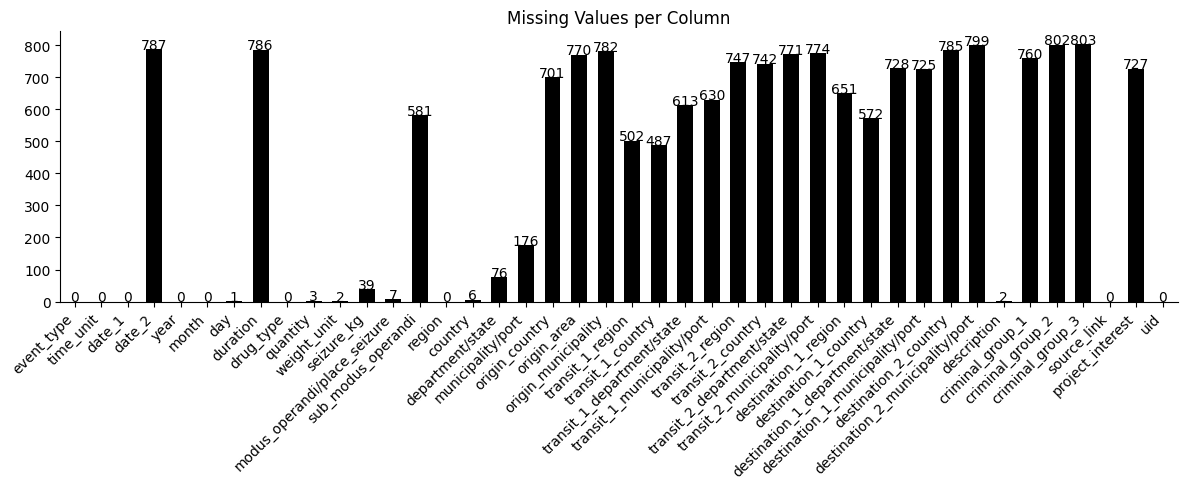

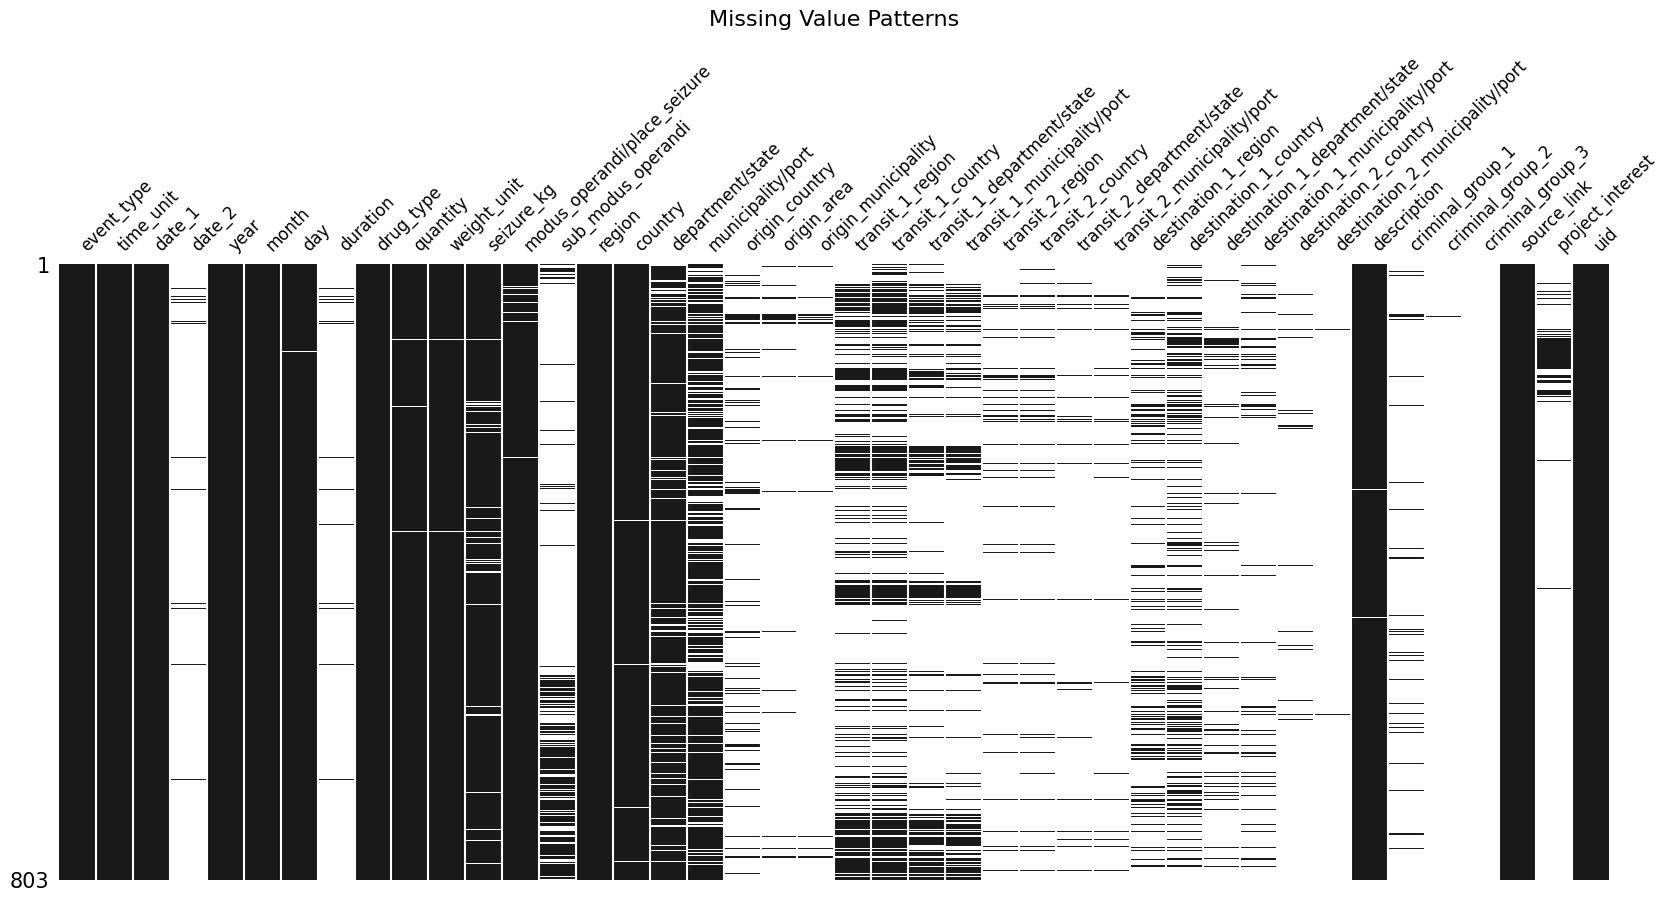

In [667]:
missing_values = df_b.isnull().sum()
print(f"Missing values per column:\n{missing_values}\n")

# Visualization 1: Bar Chart
plt.figure(figsize=(12, 5))
ax = missing_values.plot(kind='bar', color="#000000", width=0.6)
ax.grid(False)
for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height()+1, 
            f'{int(i.get_height())}', 
            ha='center', fontsize=10)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.title("Missing Values per Column")
plt.tight_layout()
plt.show()

# Visualization 2: Missingno Matrix
msno.matrix(
    df_b,
    figsize=(20, 8),
    color=(0.1, 0.1, 0.1),
    sparkline=False,
    fontsize=12,
    labels=True
)
plt.title("Missing Value Patterns", fontsize=16, pad=20)
plt.show()

### Indicators

###### Monthly seizures

/tmp/ipykernel_14644/2958638131.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
/tmp/ipykernel_14644/2958638131.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
/tmp/ipykernel_14644/2958638131.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
/tmp/ipykernel_14644/2958638131.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
/tmp/ipykernel_14644/2958638131.py:60: FutureWarning: DataFrame.appl

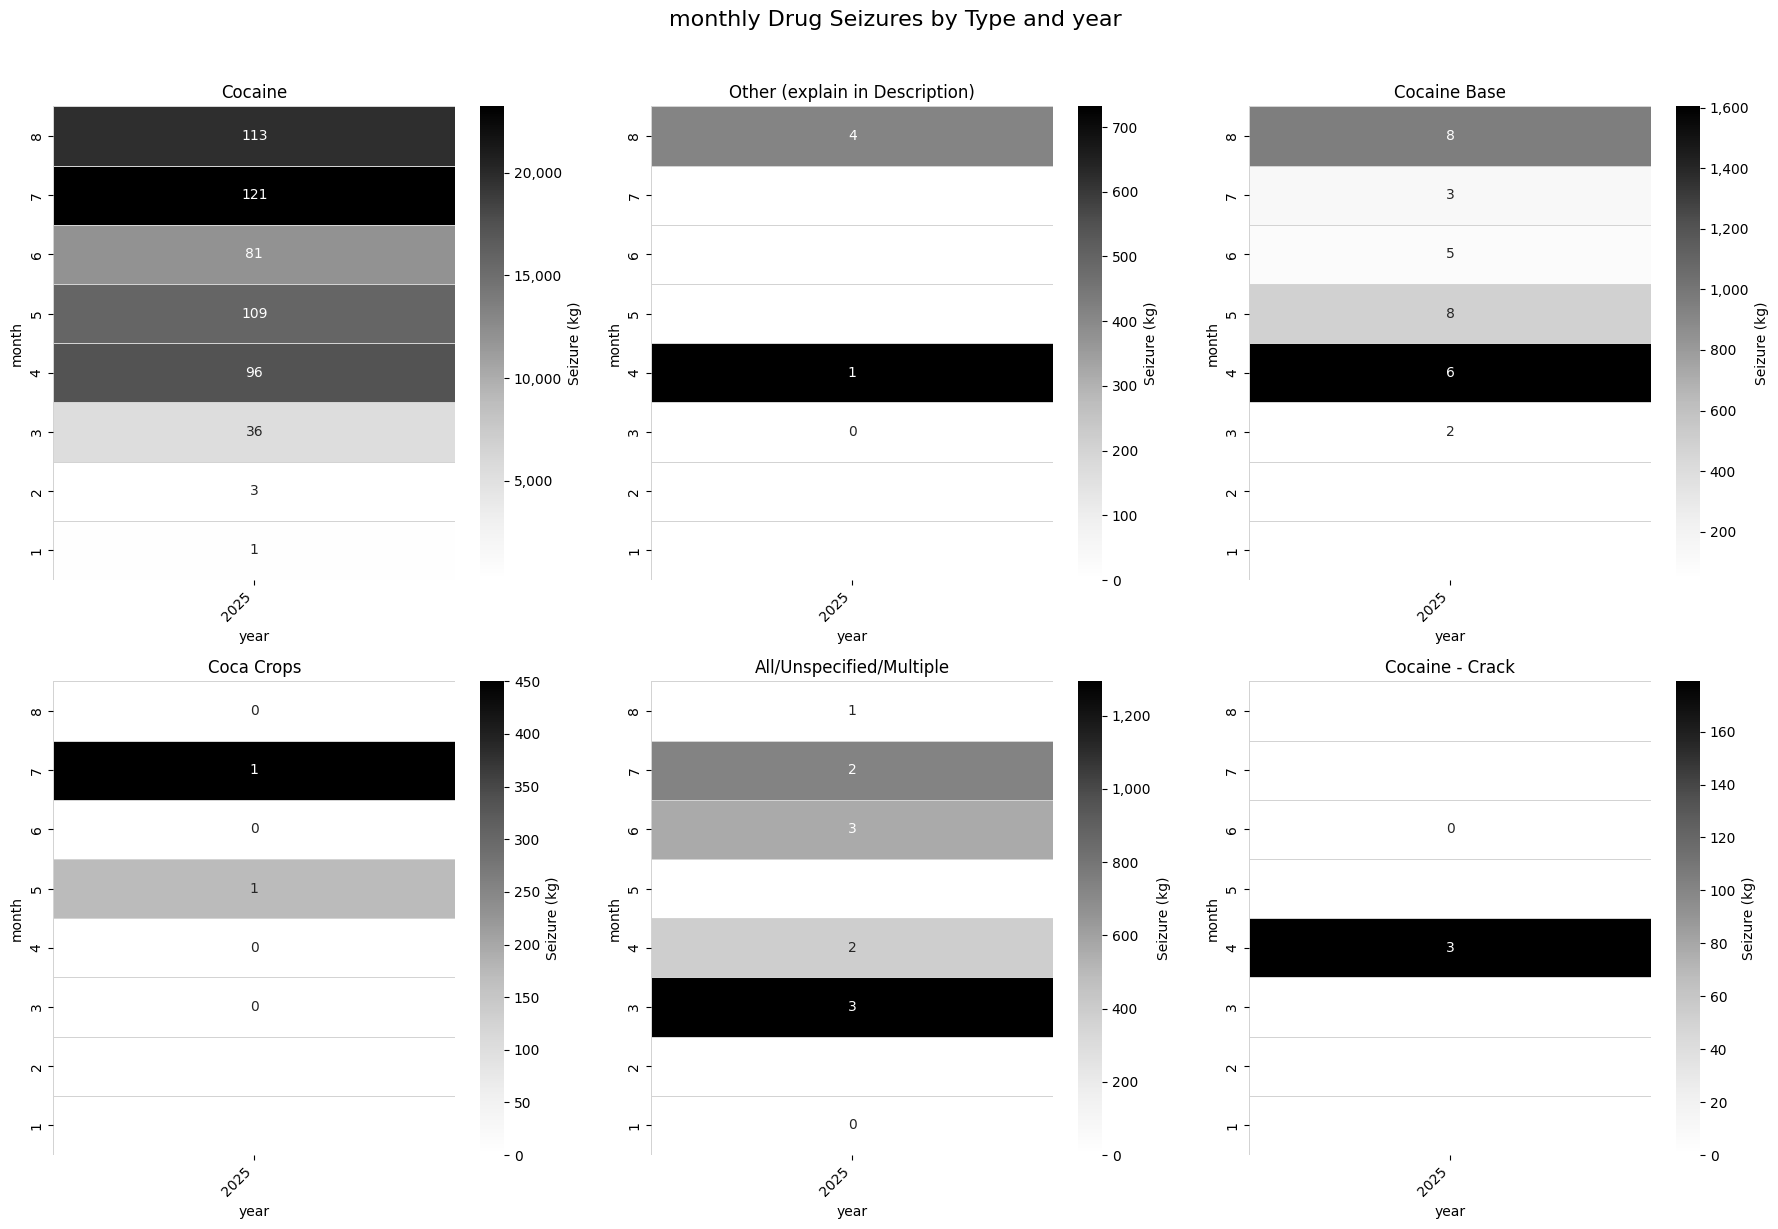

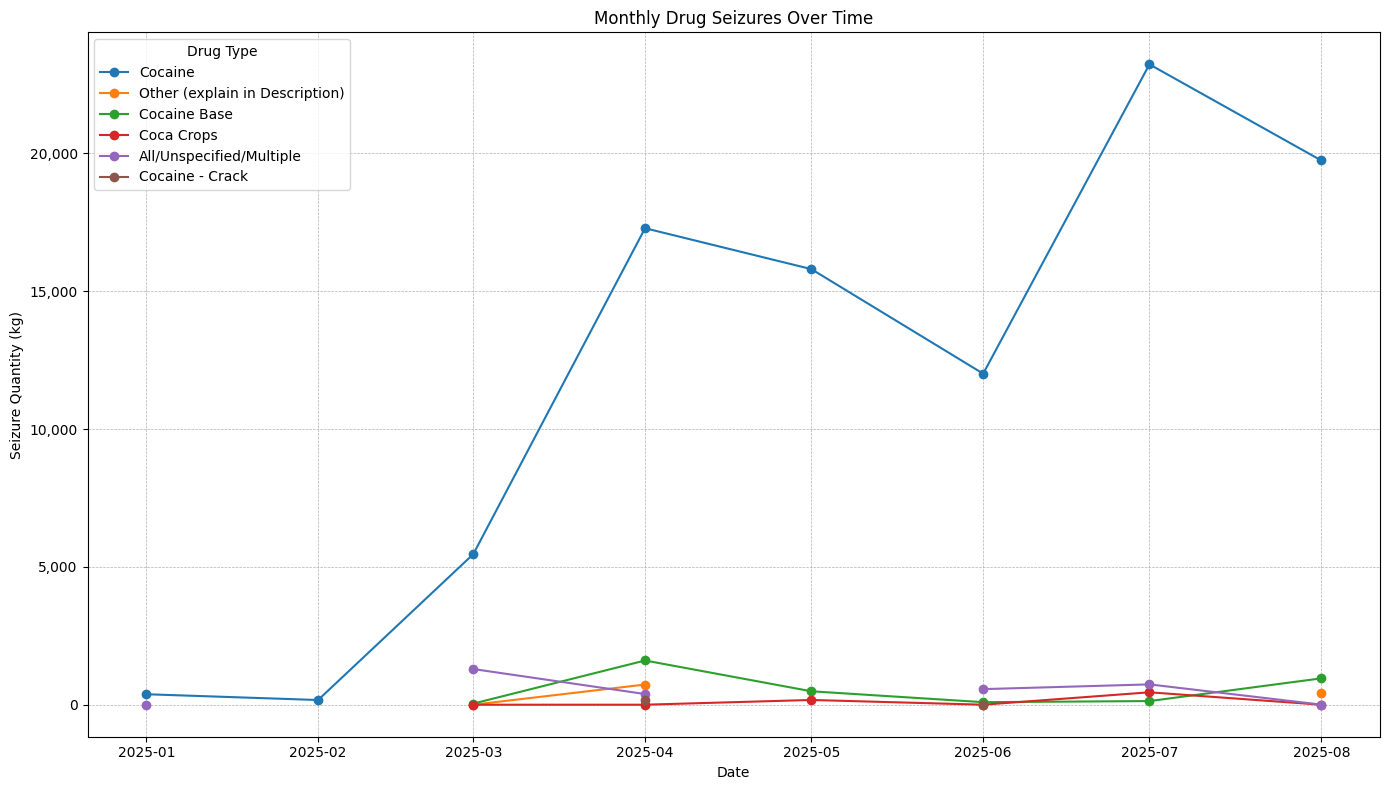

In [668]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.ticker import FuncFormatter

# Clean the data - remove rows where drug_type is None/NaN
df_b = df_b.dropna(subset=['drug_type'])

# Convert and clean seizure data
df_b['seizure_kg'] = pd.to_numeric(df_b['seizure_kg'], errors='coerce')

# Create pivot tables grouped by drug_type
pivot_data = df_b.groupby(['year', 'month', 'drug_type']).agg(
    seizure_kg=('seizure_kg', 'sum'),
    event_count=('seizure_kg', 'count')
).unstack(level=[0, 2])  # Unstack both year and drug_type

# Extract components
seizure_kg = pivot_data['seizure_kg']
event_counts = pivot_data['event_count']

# Fill NaN values with 0
seizure_kg_filled = seizure_kg.fillna(0)

# Get unique drug types for plotting
drug_types = df_b['drug_type'].unique()

# Calculate grid dimensions
n_drugs = len(drug_types)
n_cols = 3  # You can adjust this based on your preference
n_rows = math.ceil(n_drugs / n_cols)

# Create figure for grid layout
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
fig.suptitle("monthly Drug Seizures by Type and year", y=1.02, fontsize=16)

# Flatten axes array for easy iteration
if n_rows > 1:
    axes = axes.flatten()
else:
    axes = [axes] if n_cols == 1 else axes

# Function to format numbers with commas
def format_with_commas(x, pos):
    return f"{x:,.0f}"

# Create formatter
comma_formatter = FuncFormatter(format_with_commas)

# Plot heatmap for each drug type in the grid
for i, drug in enumerate(drug_types):
    ax = axes[i]
    
    # Filter data for current drug type
    drug_kg = seizure_kg.xs(drug, level=1, axis=1)
    drug_counts = event_counts.xs(drug, level=1, axis=1)
    
    # Create annotation text with commas
    annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
    
    heatmap = sns.heatmap(
        drug_kg.sort_index(ascending=False),
        cmap="Greys",
        annot=annot_text,
        fmt='',  # Empty string since we pre-formatted
        cbar_kws={'label': f'Seizure (kg)', 'format': comma_formatter},
        linewidths=0.5,
        linecolor='lightgray',
        ax=ax
    )
    
    # Format colorbar ticks with commas
    if heatmap.collections[0].colorbar is not None:
        heatmap.collections[0].colorbar.ax.yaxis.set_major_formatter(comma_formatter)
    
    ax.set_title(drug)
    ax.set_ylabel("month")
    ax.set_xlabel("year")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Hide any empty subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Line graph version with comma formatting
plt.figure(figsize=(14,8))

# Create date column for proper time series plotting
df_b['date'] = pd.to_datetime(df_b['year'].astype(str) + '-' + df_b['month'] + '-01')

# Group by date and drug type
line_data = df_b.groupby(['date', 'drug_type'])['seizure_kg'].sum().unstack()

# Plot each drug type
for drug in drug_types:
    if drug in line_data.columns:
        plt.plot(line_data.index, line_data[drug], marker='o', label=drug)

plt.title("Monthly Drug Seizures Over Time")
plt.ylabel("Seizure Quantity (kg)")
plt.xlabel("Date")
plt.legend(title="Drug Type")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Format y-axis with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_with_commas))

plt.tight_layout()
plt.show()


###### Routes

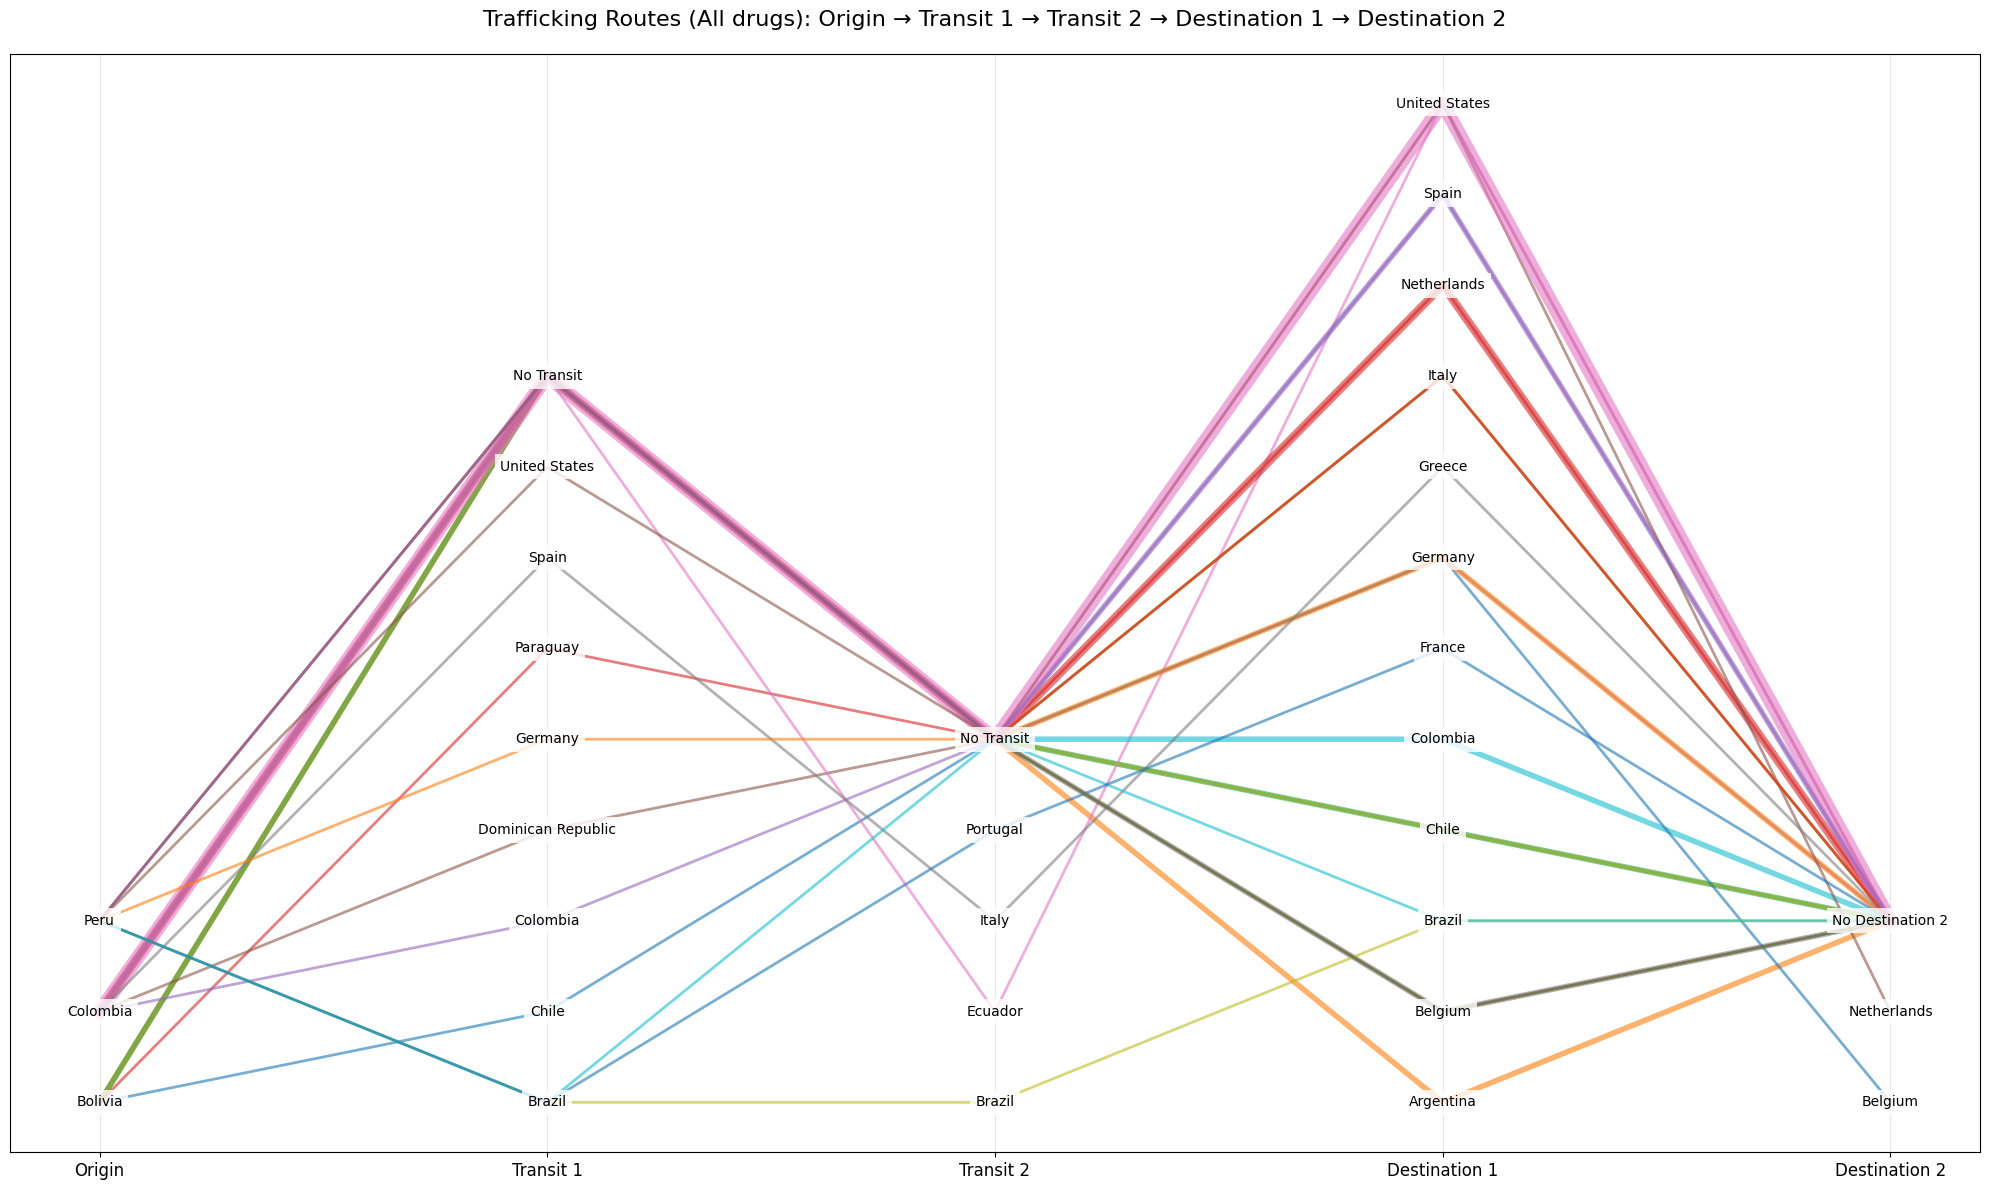

In [669]:
import matplotlib.pyplot as plt

def plot_parallel_sets(df_b): 
    # Define the column names
    columns = ['origin_country', 'transit_1_country', 'transit_2_country', 
         'destination_1_country', 'destination_2_country']
    
    # Copy and fill missing values
    df_b = df_b[columns].copy()
    df_b[columns[1]] = df_b[columns[1]].fillna('No Transit')
    df_b[columns[2]] = df_b[columns[2]].fillna('No Transit')
    df_b[columns[4]] = df_b[columns[4]].fillna('No Destination 2')
    
    # Filter incomplete rows
    df_b.dropna(subset=[columns[0], columns[3]], inplace=True)
    if df_b.empty:
        print("Warning: No data with both origin and destination information")
        return
    
    # Count path frequencies
    path_counts = df_b.groupby(columns).size().reset_index(name='count')
    
    # Prepare the plot
    plt.figure(figsize=(20, 12))

    # Map each category to a y-position (starting at 1)
    categories = {}
    for col in columns:
        values = df_b[col].unique()
        sorted_vals = sorted([v for v in values if "No" not in v]) + sorted([v for v in values if "No" in v])
        categories[col] = {val: idx + 1 for idx, val in enumerate(sorted_vals)}
    
    # Plot each path
    for _, row in path_counts.iterrows():
        y_values = [categories[col][row[col]] for col in columns]
        plt.plot(range(len(columns)), y_values, linewidth=row['count'] * 2, alpha=0.6)

    # X-axis: step names
    plt.xticks(range(len(columns)), ['Origin', 'Transit 1', 'Transit 2', 'Destination 1', 'Destination 2'], fontsize=12)
    
    # Y-axis: remove default numbers
    plt.yticks([])
    
    # Add node labels
    for i, col in enumerate(columns):
        for val, y in categories[col].items():
            plt.text(i, y, val, ha='center', va='center',
                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'), fontsize=10)
    
    # Final touches
    plt.title("Trafficking Routes (All drugs): Origin → Transit 1 → Transit 2 → Destination 1 → Destination 2", 
              fontsize=16, pad=20)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_parallel_sets(df_b)

###### Modus operandi

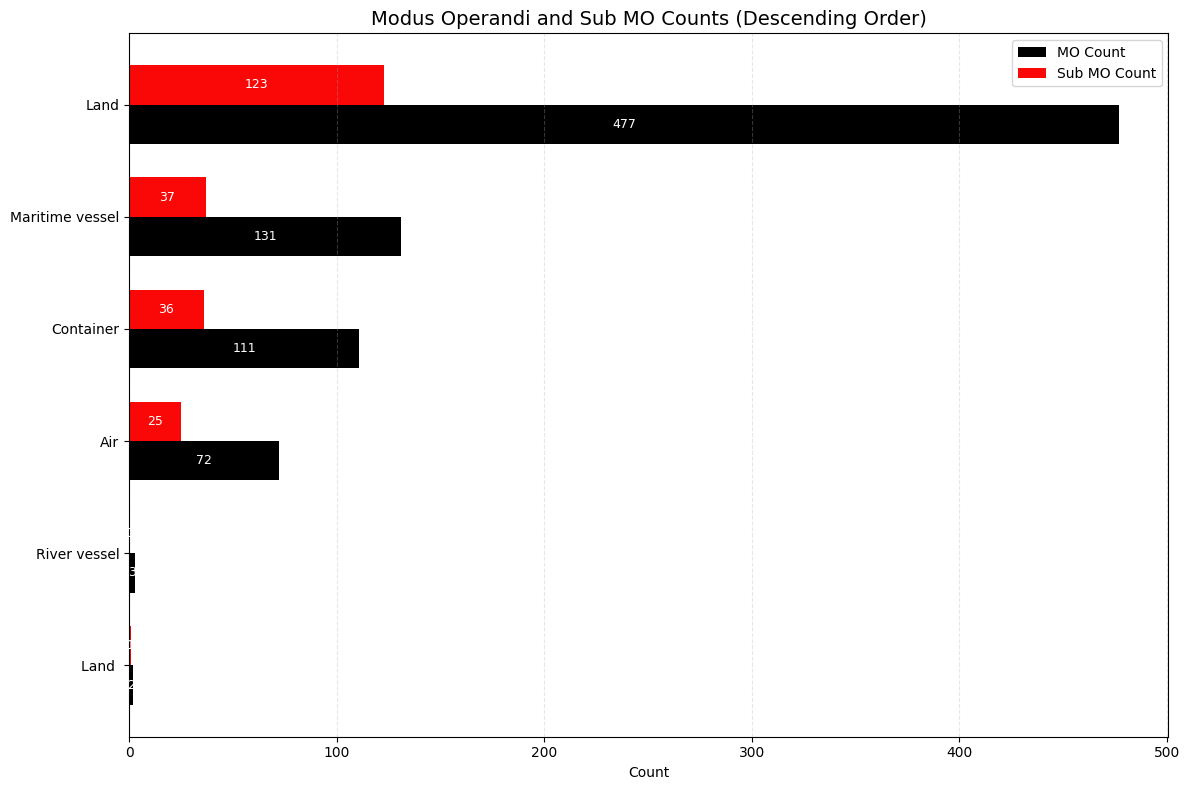

In [670]:
import numpy as np
import matplotlib.pyplot as plt

# Group counts and sort 
mo = df_b['modus_operandi/place_seizure'].value_counts().sort_values(ascending=True)
sub_mo = df_b.groupby('modus_operandi/place_seizure')['sub_modus_operandi'].count().reindex(mo.index)

# Plot horizontal bars
labels = mo.index
y = np.arange(len(labels))
h = 0.35

fig, ax = plt.subplots(figsize=(12, 8))
b1 = ax.barh(y - h/2, mo, h, label='MO Count', color="#000000")
b2 = ax.barh(y + h/2, sub_mo, h, label='Sub MO Count', color="#FA0707")

# Label bars
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                str(int(bar.get_width())), ha='center', va='center', color='white', fontsize=9)

# Style
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_title('Modus Operandi and Sub MO Counts (Descending Order)', fontsize=14)
ax.legend()
ax.set_xlabel('Count')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()